# H-CAST Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares:

- baseline `/scratch/g.saggini1/outputs/hcast_cifar100`
- temperature variants from runs matching `/scratch/g.saggini1/outputs/hcast_hcc_cifar100*`

It includes:
- validation curves for `fpa_topdown` and `weighted_ap_topdown`,
- per-level validation top-down accuracy curves,
- a final test comparison table with deltas,
- projection diagnostics (`proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, etc.),
- short interpretation snippets after each analysis block.


In [40]:
from pathlib import Path
import json
import re

import numpy as np
import yaml
import matplotlib.pyplot as plt
try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

def show_markdown(text):
    is_jupyter = False
    try:
        from IPython import get_ipython
        shell = get_ipython()
        is_jupyter = bool(shell) and shell.__class__.__name__ == 'ZMQInteractiveShell'
    except Exception:
        is_jupyter = False

    if is_jupyter and Markdown is not None and display is not None:
        display(Markdown(text))
    else:
        print(text)


plt.style.use('seaborn-v0_8-whitegrid')

def resolve_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / 'configs').exists():
            return candidate
    return cwd


PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [41]:
_ACC_LEVEL_PATTERN = re.compile(r'^acc_level_(\\d+)$')
_ACC_LEVEL_TOPDOWN_PATTERN = re.compile(r'^acc_level_topdown_(\\d+)$')
_ACC_LEVEL_INDEPENDENT_PATTERN = re.compile(r'^acc_level_independent_(\\d+)$')


def _as_float_dict(metrics):
    out = {}
    if not isinstance(metrics, dict):
        return out
    for key, value in metrics.items():
        try:
            out[str(key)] = float(value)
        except (TypeError, ValueError):
            continue
    return out


def normalize_metrics(metrics):
    """Normalize metric key variants from older/newer logs into one schema."""
    out = _as_float_dict(metrics)

    # Weighted AP aliases
    if 'weighted_ap_topdown' not in out:
        if 'weighted_ap' in out:
            out['weighted_ap_topdown'] = out['weighted_ap']
        elif 'weighted_ap_independent' in out:
            out['weighted_ap_topdown'] = out['weighted_ap_independent']
    if 'weighted_ap_independent' not in out and 'weighted_ap_topdown' in out:
        out['weighted_ap_independent'] = out['weighted_ap_topdown']

    # FPA aliases
    if 'fpa_topdown' not in out:
        if 'fpa' in out:
            out['fpa_topdown'] = out['fpa']
        elif 'fpa_independent' in out:
            out['fpa_topdown'] = out['fpa_independent']
    if 'fpa_independent' not in out and 'fpa_topdown' in out:
        out['fpa_independent'] = out['fpa_topdown']

    # TICE aliases
    if 'tice_topdown' not in out:
        if 'tice' in out:
            out['tice_topdown'] = out['tice']
        elif 'tice_independent' in out:
            out['tice_topdown'] = out['tice_independent']
    if 'tice_independent' not in out and 'tice_topdown' in out:
        out['tice_independent'] = out['tice_topdown']

    # AHD aliases
    if 'ahd_topdown' not in out:
        if 'ahd' in out:
            out['ahd_topdown'] = out['ahd']
        elif 'ahd_independent' in out:
            out['ahd_topdown'] = out['ahd_independent']
    if 'ahd_independent' not in out and 'ahd_topdown' in out:
        out['ahd_independent'] = out['ahd_topdown']

    # Legacy per-level accuracy aliases (acc_level_{i})
    for key, value in list(out.items()):
        match = _ACC_LEVEL_PATTERN.match(key)
        if match:
            level_idx = int(match.group(1))
            out.setdefault(f'acc_level_independent_{level_idx}', value)
            out.setdefault(f'acc_level_topdown_{level_idx}', value)

    # Fill missing top-down/independent level metrics from each other when only one exists.
    level_ids = set()
    for key in list(out.keys()):
        match = _ACC_LEVEL_TOPDOWN_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))
            continue
        match = _ACC_LEVEL_INDEPENDENT_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))

    for level_idx in level_ids:
        topdown_key = f'acc_level_topdown_{level_idx}'
        independent_key = f'acc_level_independent_{level_idx}'
        if topdown_key not in out and independent_key in out:
            out[topdown_key] = out[independent_key]
        if independent_key not in out and topdown_key in out:
            out[independent_key] = out[topdown_key]

    return out


def load_jsonl_events(path):
    events = []
    with Path(path).open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
    return events


def load_yaml(path):
    with Path(path).open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def metric_for_best(metrics):
    """Mirror train.utils.metric_for_best for consistent best-epoch selection."""
    m = normalize_metrics(metrics)

    has_fpa = 'fpa_topdown' in m
    has_tice = 'tice_topdown' in m
    has_wap = 'weighted_ap_topdown' in m

    if has_fpa or has_tice or has_wap:
        fpa = float(m.get('fpa_topdown', 0.0))
        neg_tice = -float(m.get('tice_topdown', 1.0))
        wap = float(m.get('weighted_ap_topdown', 0.0))
        return float(fpa + 1e-3 * neg_tice + 1e-6 * wap)

    topdown_keys = [
        key
        for key in m
        if key.startswith('acc_level_topdown_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    independent_keys = [
        key
        for key in m
        if key.startswith('acc_level_independent_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    deepest = topdown_keys or independent_keys
    if not deepest:
        return float(m.get('fpa_topdown', 0.0))

    deepest_key = max(deepest, key=lambda key: int(key.rsplit('_', 1)[-1]))
    primary = float(m.get(deepest_key, 0.0))
    tie = float(m.get('fpa_topdown', 0.0))
    return float(primary + 1e-3 * tie)


def parse_run(run_dir):
    run_path = Path(run_dir)
    events = load_jsonl_events(run_path / 'run_log.jsonl')
    epoch_events = [event for event in events if event.get('event') == 'epoch']

    for event in epoch_events:
        event['train_metrics_norm'] = normalize_metrics(event.get('train_metrics', {}))
        event['val_metrics_norm'] = normalize_metrics(event.get('val_metrics', {}))
        event['rank_score'] = metric_for_best(event['val_metrics_norm'])

    test_events = [event for event in events if event.get('event') == 'test']
    test_event = test_events[-1] if test_events else {}
    test_metrics = normalize_metrics(test_event.get('test_metrics', {}))

    test_metrics_yaml = {}
    test_yaml_path = run_path / 'test_metrics.yaml'
    if test_yaml_path.exists():
        test_metrics_yaml = load_yaml(test_yaml_path) or {}
        if not test_metrics:
            test_metrics = normalize_metrics(test_metrics_yaml.get('test_metrics', {}))

    level_names = []
    cfg_path = run_path / 'config_resolved.yaml'
    if cfg_path.exists():
        cfg = load_yaml(cfg_path) or {}
        level_names = list(cfg.get('dataset', {}).get('levels', []))

    best_epoch_event = None
    if epoch_events:
        best_idx = int(np.argmax([event['rank_score'] for event in epoch_events]))
        best_epoch_event = epoch_events[best_idx]

    return {
        'run_dir': run_path,
        'events': events,
        'epoch_events': epoch_events,
        'test_event': test_event,
        'test_metrics': test_metrics,
        'test_metrics_yaml': test_metrics_yaml,
        'level_names': level_names,
        'best_epoch_event': best_epoch_event,
    }


def get_metric_series(epoch_events, metric_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event['val_metrics_norm'].get(metric_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)


def get_level_label(level_idx, run_data):
    names = run_data.get('level_names') or []
    if level_idx < len(names):
        return str(names[level_idx])
    return f'L{level_idx}'


In [42]:
INCLUDE_BASELINES = True
BASELINE_COLOR = '#1f77b4'

# Baselines keyed by dataset name (case-insensitive).
# Keys should match `dataset.name` in each run config (or manual `dataset_name`).
# Example:
BASELINE_BY_DATASET = {
    'cifar100': {'run_dir': 'hcast_cifar100', 'label': 'H-CAST'},
    'cub200': {'run_dir': 'hcast_cub200', 'label': 'H-CAST'},
    'fgvcaircraft': {'run_dir': 'hcast_aircraft', 'label': 'H-CAST'},
}

# Preferred: explicit run list (full control over what is shown).
# Use absolute or OUTPUTS_ROOT-relative paths.
MANUAL_RUNS = [
    {'run_dir': 'hcast_hcc_cifar100_step_100epochs', 'label': 'HCC step epoch 100', 'color': '#d62728'},
    {'run_dir': 'hcast_hcc_cub200_step_100epochs', 'label': 'HCC step epoch 100', 'color': '#d62728'},
    {'run_dir': 'hcast_hcc_cub200_linear_100epochs', 'label': 'HCC linear epoch 100', 'color': "#27d66d"},
    {'run_dir': 'hcast_hcc_aircraft_step_100epochs', 'label': 'HCC step epoch 100', 'color': '#d62728'},
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728', '#2ca02c', '#ff7f0e', '#9467bd',
    '#8c564b', '#17becf', '#e377c2', '#bcbd22',
]


def _resolve_run_dir(path_like):
    path = Path(path_like)
    if path.is_absolute():
        return path
    return OUTPUTS_ROOT / path


def _read_hcc_cfg(run_dir):
    cfg_path = Path(run_dir) / 'config_resolved.yaml'
    if not cfg_path.exists():
        return {}
    cfg = load_yaml(cfg_path) or {}

    # New canonical location.
    hcc_cfg = cfg.get('hcc', None)
    if isinstance(hcc_cfg, dict):
        return dict(hcc_cfg)

    # Backward-compatible fallback.
    hcc_cfg = cfg.get('model', {}).get('hcc', {})
    if not isinstance(hcc_cfg, dict):
        return {}
    return dict(hcc_cfg)


def _read_dataset_name(run_dir):
    cfg_path = Path(run_dir) / 'config_resolved.yaml'
    if not cfg_path.exists():
        return None
    cfg = load_yaml(cfg_path) or {}
    dataset_cfg = cfg.get('dataset', {})
    if not isinstance(dataset_cfg, dict):
        return None
    raw_name = dataset_cfg.get('name', None)
    if raw_name is None:
        return None
    return str(raw_name)


def _normalize_dataset_key(value):
    if value is None:
        return None
    normalized = ''.join(ch for ch in str(value).strip().lower() if ch.isalnum())
    return normalized or None


def _read_hcc_temperature(run_dir):
    hcc_cfg = _read_hcc_cfg(run_dir)
    raw_temp = hcc_cfg.get('temperature', None)
    if raw_temp is None:
        return None
    try:
        return float(raw_temp)
    except (TypeError, ValueError):
        return None


def _read_hcc_projection_mode(run_dir):
    hcc_cfg = _read_hcc_cfg(run_dir)
    mode = hcc_cfg.get('projection_mode', None)
    if mode is None:
        return None
    return str(mode)


def _read_hcc_constraint_strength_max(run_dir):
    hcc_cfg = _read_hcc_cfg(run_dir)
    raw = hcc_cfg.get('constraint_strength_max', None)
    if raw is None:
        return None
    try:
        value = float(raw)
    except (TypeError, ValueError):
        return None
    return min(max(value, 0.0), 1.0)


def _run_meta_from_dir(run_dir):
    return {
        'run_dir': Path(run_dir),
        'temperature': _read_hcc_temperature(run_dir),
        'hcc_projection_mode': _read_hcc_projection_mode(run_dir),
        'hcc_constraint_strength_max': _read_hcc_constraint_strength_max(run_dir),
        'dataset_name': _read_dataset_name(run_dir),
    }


def _build_runs_from_manual():
    if not MANUAL_RUNS:
        raise ValueError('MANUAL_RUNS is empty. Add explicit runs to plot.')

    runs = []
    for idx, spec in enumerate(MANUAL_RUNS):
        if isinstance(spec, (str, Path)):
            spec = {'run_dir': spec}

        run_dir = _resolve_run_dir(spec['run_dir'])
        if not run_dir.exists() or not run_dir.is_dir() or not (run_dir / 'run_log.jsonl').exists():
            print(f'Skipping missing/manual-invalid run: {run_dir}')
            continue

        meta = _run_meta_from_dir(run_dir)
        temp = meta['temperature']
        default_label = f'H-CAST HCC T={temp:g}' if temp is not None else run_dir.name
        runs.append({
            'label': spec.get('label', default_label),
            'run_dir': run_dir,
            'color': spec.get('color', TEMPERATURE_COLOR_PALETTE[idx % len(TEMPERATURE_COLOR_PALETTE)]),
            'temperature': temp,
            'hcc_projection_mode': meta['hcc_projection_mode'],
            'hcc_constraint_strength_max': meta['hcc_constraint_strength_max'],
            'dataset_name': spec.get('dataset_name', meta['dataset_name']),
            'is_baseline': bool(spec.get('is_baseline', False)),
        })
    return runs


def _resolve_baseline_spec(dataset_key, baseline_lookup):
    spec = baseline_lookup.get(dataset_key)
    if spec is not None:
        return spec, dataset_key

    # Fallback: dataset keys with a trailing year (e.g., cub2002011 -> cub200).
    match = re.match(r'^(.*?)(?:19|20)\d{2}$', str(dataset_key))
    if match:
        stripped_key = match.group(1)
        spec = baseline_lookup.get(stripped_key)
        if spec is not None:
            return spec, stripped_key

    return None, None


RUNS = _build_runs_from_manual()

if INCLUDE_BASELINES:
    baseline_lookup = {
        _normalize_dataset_key(key): value
        for key, value in BASELINE_BY_DATASET.items()
        if _normalize_dataset_key(key)
    }

    selected_dataset_keys = []
    for run in RUNS:
        key = _normalize_dataset_key(run.get('dataset_name'))
        if key and key not in selected_dataset_keys:
            selected_dataset_keys.append(key)

    for dataset_key in selected_dataset_keys:
        baseline_spec, matched_key = _resolve_baseline_spec(dataset_key, baseline_lookup)
        if not baseline_spec:
            available_keys = ', '.join(sorted(baseline_lookup.keys()))
            print(f'No baseline configured for dataset key: {dataset_key}. Available keys: {available_keys}')
            continue
        if matched_key != dataset_key:
            print(f'Using baseline key {matched_key} for dataset key {dataset_key}')

        baseline_run_dir = _resolve_run_dir(baseline_spec['run_dir'])
        if not baseline_run_dir.exists() or not baseline_run_dir.is_dir() or not (baseline_run_dir / 'run_log.jsonl').exists():
            print(f'Skipping missing baseline run: {baseline_run_dir}')
            continue

        baseline_resolved = Path(baseline_run_dir).resolve()
        already_present = any(Path(run['run_dir']).resolve() == baseline_resolved for run in RUNS)
        if already_present:
            for run in RUNS:
                if Path(run['run_dir']).resolve() == baseline_resolved:
                    run['is_baseline'] = True
            continue

        baseline_meta = _run_meta_from_dir(baseline_run_dir)
        RUNS.append({
            'label': baseline_spec.get('label', 'H-CAST'),
            'run_dir': baseline_run_dir,
            'color': baseline_spec.get('color', BASELINE_COLOR),
            'temperature': baseline_meta['temperature'],
            'hcc_projection_mode': baseline_meta['hcc_projection_mode'],
            'hcc_constraint_strength_max': baseline_meta['hcc_constraint_strength_max'],
            'dataset_name': baseline_spec.get('dataset_name', baseline_meta['dataset_name']),
            'is_baseline': True,
        })

if not RUNS:
    raise ValueError('No runs found. Check MANUAL_RUNS.')

run_data_list = []
for run in RUNS:
    parsed = parse_run(run['run_dir'])
    parsed.update(run)
    dataset_name = parsed.get('dataset_name')
    if not dataset_name:
        level_names = [str(name) for name in (parsed.get('level_names') or [])]
        if level_names:
            dataset_name = '/'.join(level_names)
        else:
            dataset_name = parsed['run_dir'].name
    parsed['dataset_name'] = str(dataset_name)
    parsed['dataset_key'] = _normalize_dataset_key(parsed['dataset_name']) or parsed['dataset_name']
    parsed['_run_order'] = len(run_data_list)
    run_data_list.append(parsed)

run_data_by_dataset = {}
for run_data in run_data_list:
    run_data_by_dataset.setdefault(run_data['dataset_key'], []).append(run_data)

for dataset_key, dataset_runs in run_data_by_dataset.items():
    dataset_runs.sort(key=lambda run: (0 if run.get('is_baseline') else 1, run.get('_run_order', 0)))

dataset_keys = list(run_data_by_dataset.keys())

for dataset_key in dataset_keys:
    for run_data in run_data_by_dataset[dataset_key]:
        epoch_count = len(run_data['epoch_events'])
        best_epoch = run_data['best_epoch_event']['epoch'] if run_data['best_epoch_event'] else None
        best_score = run_data['best_epoch_event']['rank_score'] if run_data['best_epoch_event'] else None
        temperature = run_data.get('temperature', None)
        projection_mode = run_data.get('hcc_projection_mode', None)
        strength_max = run_data.get('hcc_constraint_strength_max', None)
        dataset_name = run_data.get('dataset_name', 'unknown')
        is_baseline = bool(run_data.get('is_baseline', False))

        temp_txt = '' if temperature is None else f', T={temperature:g}'
        mode_txt = '' if projection_mode is None else f', proj_mode={projection_mode}'
        if strength_max is None or not np.isfinite(strength_max):
            strength_txt = ''
        else:
            strength_txt = f', strength_max={strength_max:g}'
        baseline_txt = ', baseline' if is_baseline else ''

        print(
            f"[{dataset_name}] {run_data['label']}: epochs={epoch_count}, best_epoch={best_epoch}, "
            f"best_score={best_score}{temp_txt}{mode_txt}{strength_txt}{baseline_txt}"
        )


Using baseline key cub200 for dataset key cub2002011
[cifar-100] H-CAST: epochs=100, best_epoch=96, best_score=0.7497078064483643, baseline
[cifar-100] HCC step epoch 100: epochs=115, best_epoch=102, best_score=0.7502937444915772, T=10
[cub-200-2011] H-CAST: epochs=100, best_epoch=99, best_score=0.8115065272002325, baseline
[cub-200-2011] HCC step epoch 100: epochs=115, best_epoch=109, best_score=0.8198161967985091, T=10
[cub-200-2011] HCC linear epoch 100: epochs=115, best_epoch=110, best_score=0.8240775632013753, T=10
[fgvc-aircraft] H-CAST: epochs=100, best_epoch=63, best_score=0.7340967657226563, baseline
[fgvc-aircraft] HCC step epoch 100: epochs=115, best_epoch=105, best_score=0.7449784709960938, T=10


## H-CAST Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


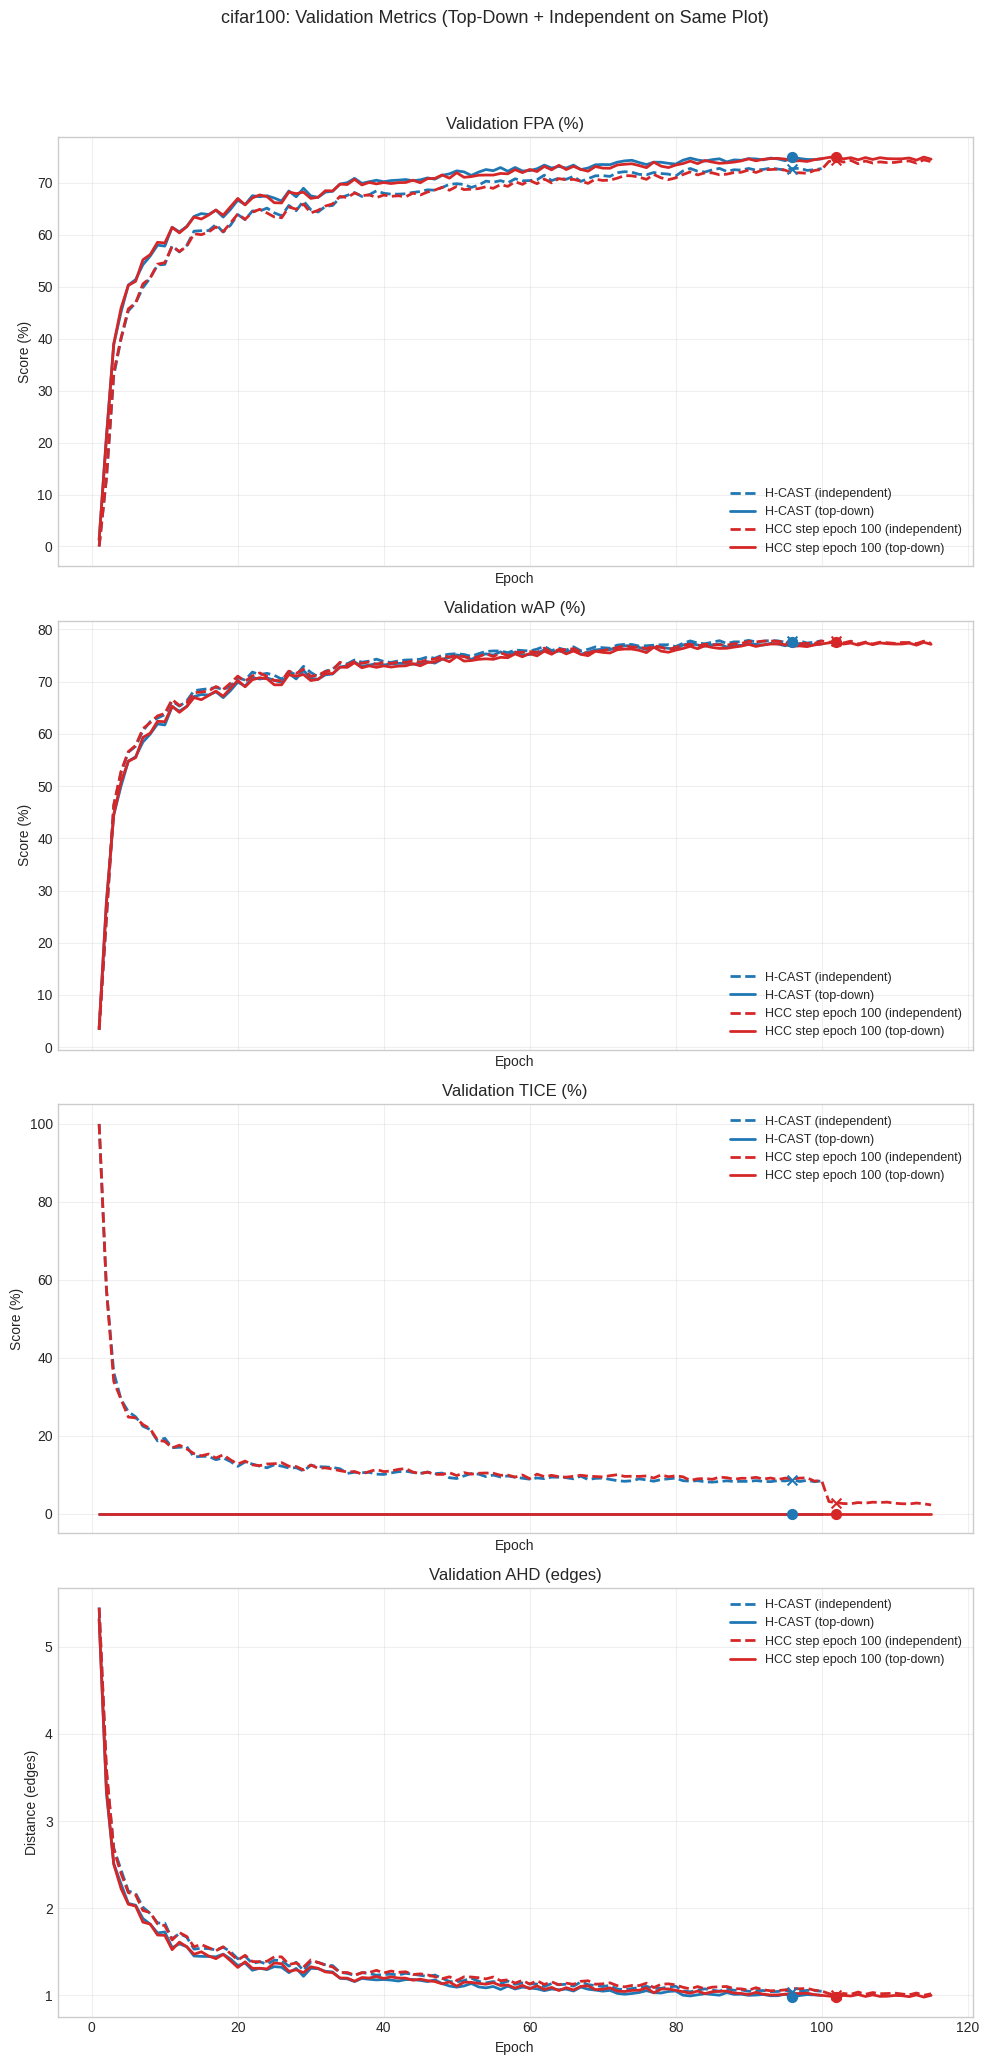

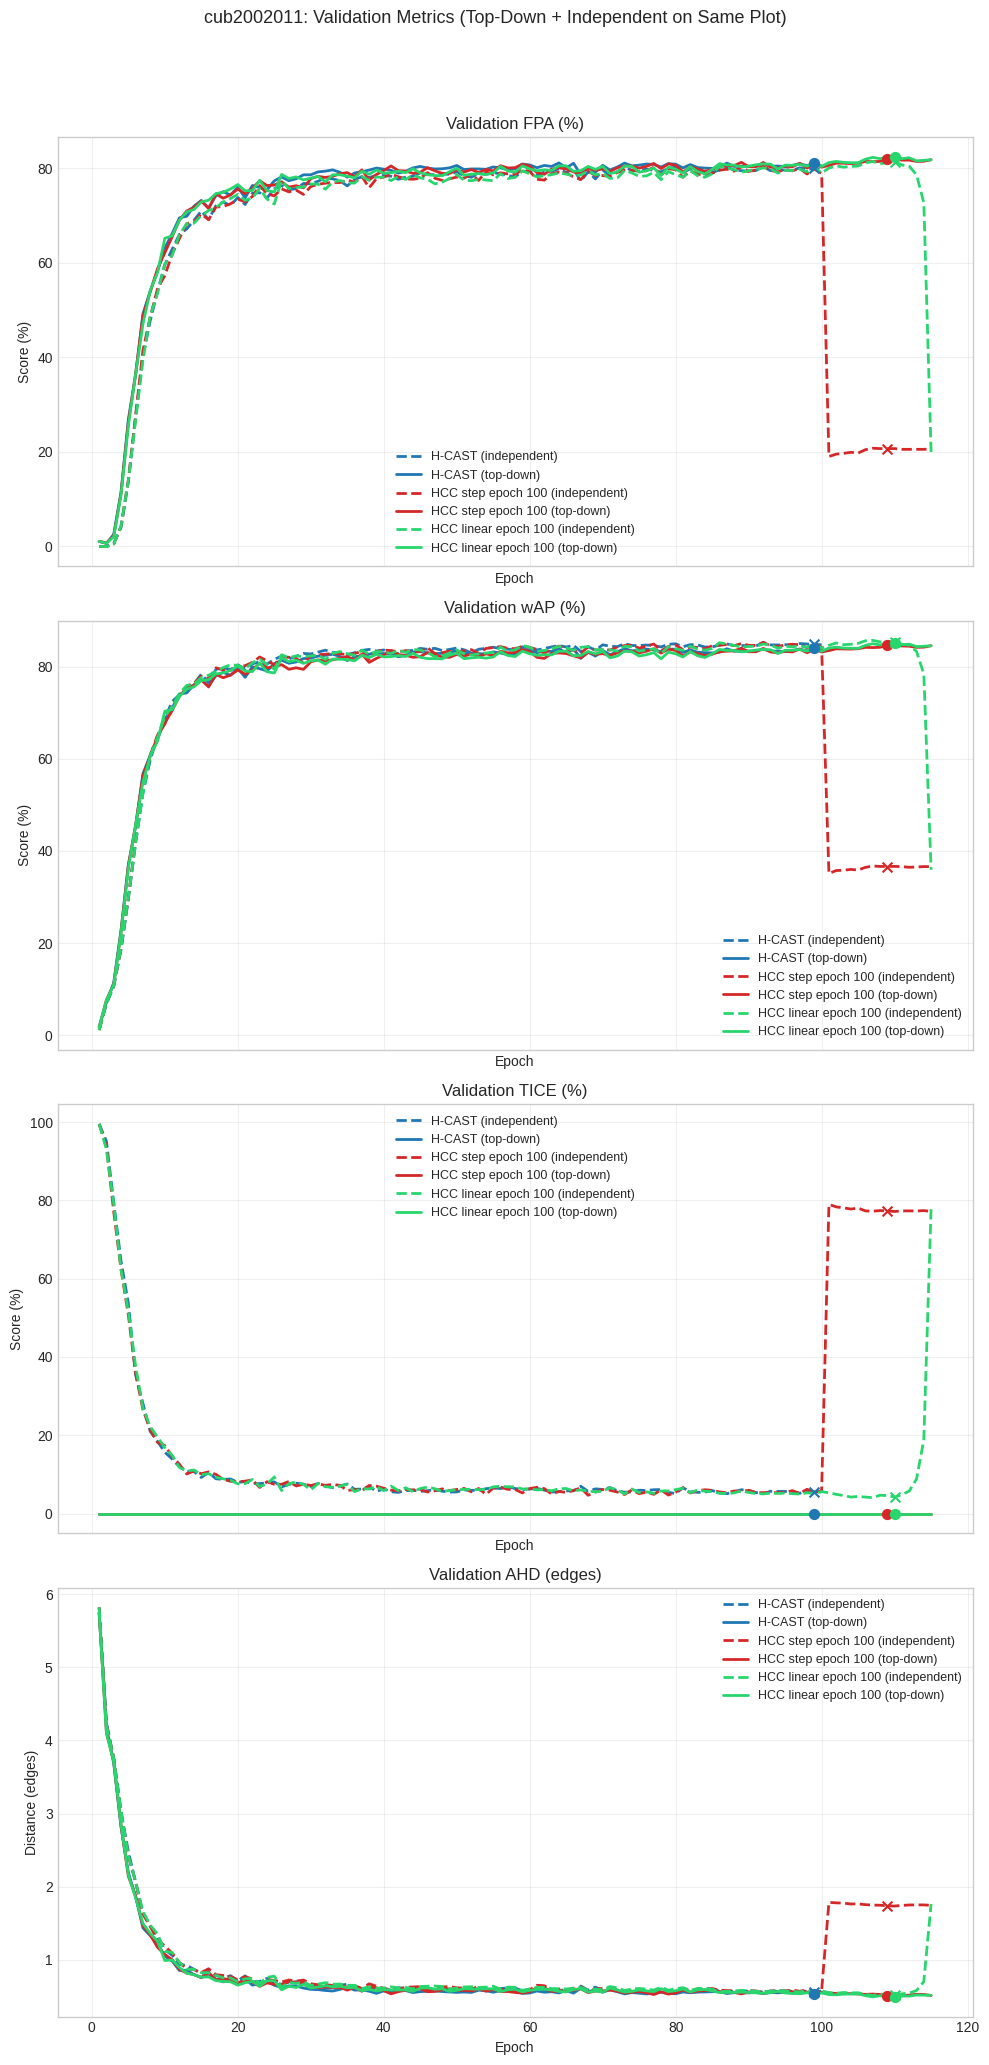

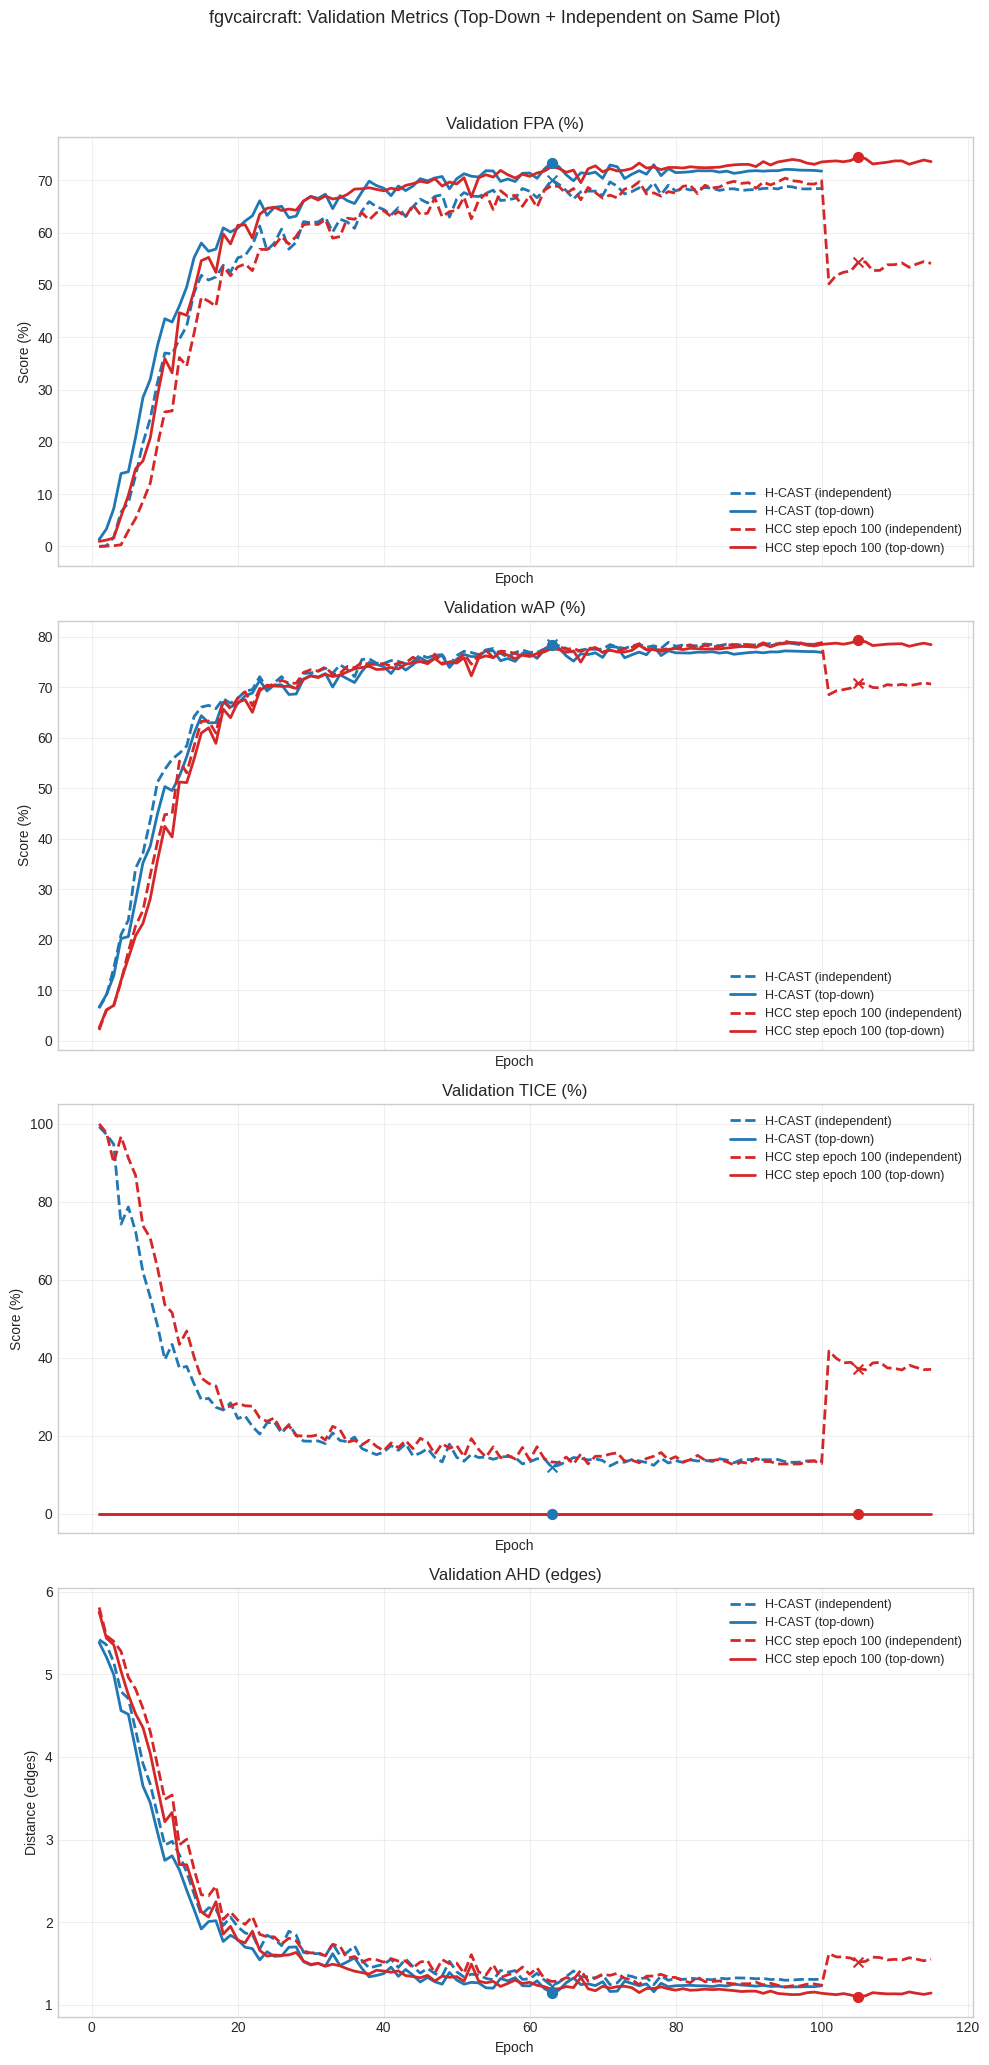

In [43]:
metric_families = [
    ('fpa', 'Validation FPA (%)', True),
    ('weighted_ap', 'Validation wAP (%)', True),
    ('tice', 'Validation TICE (%)', True),
    ('ahd', 'Validation AHD (edges)', False),
]
mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

for dataset_key in dataset_keys:
    dataset_runs = run_data_by_dataset.get(dataset_key, [])
    if not dataset_runs:
        continue

    fig, axes = plt.subplots(len(metric_families), 1, figsize=(10, 5 * len(metric_families)), sharex=True)
    if len(metric_families) == 1:
        axes = [axes]

    for ax, (metric_prefix, metric_title, is_percent) in zip(axes, metric_families):
        for run_data in dataset_runs:
            for mode_key, line_style, mode_label, marker in mode_specs:
                metric_key = f'{metric_prefix}_{mode_key}'
                epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
                plot_values = values * 100.0 if is_percent else values
                ax.plot(
                    epochs,
                    plot_values,
                    label=f"{run_data['label']} ({mode_label})",
                    color=run_data['color'],
                    linestyle=line_style,
                    linewidth=2.0,
                )

                best_event = run_data['best_epoch_event']
                if best_event is not None:
                    best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                    if np.isfinite(best_value):
                        best_plot_value = best_value * 100.0 if is_percent else best_value
                        ax.scatter(
                            [best_event['epoch']],
                            [best_plot_value],
                            color=run_data['color'],
                            marker=marker,
                            s=50,
                            zorder=4,
                        )

        ax.set_title(metric_title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score (%)' if is_percent else 'Distance (edges)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.suptitle(f'{dataset_key}: Validation Metrics (Top-Down + Independent on Same Plot)', y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (HCC)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha` (annealing blend/schedule value),
- `proj_constraint_strength` (intrinsic projection strength),
- `proj_temperature`,
- `proj_mode_intrinsic_soft`,
- `proj_has_negative` and per-level `proj_neg_frac_level_*`.


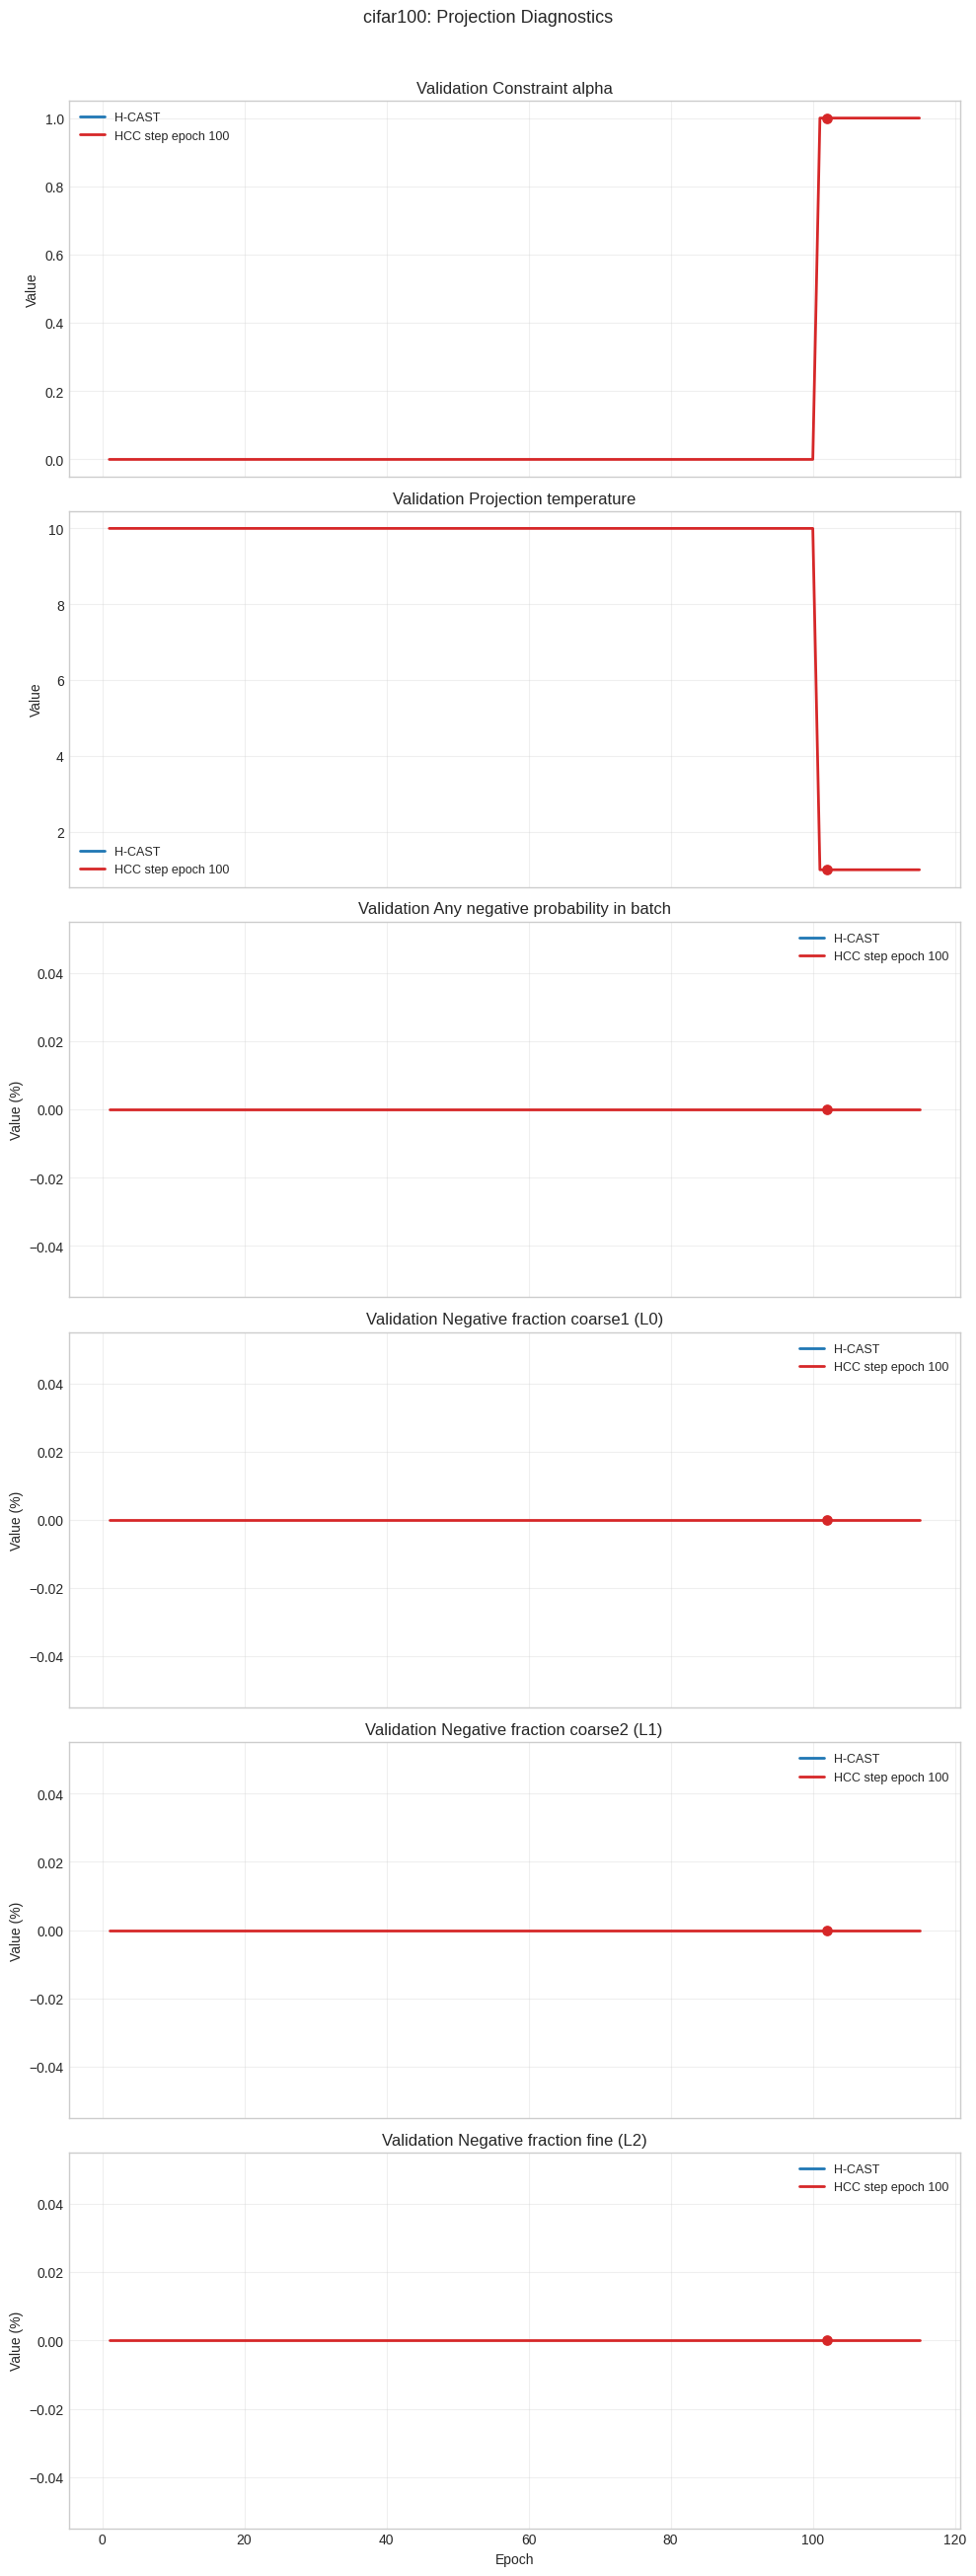

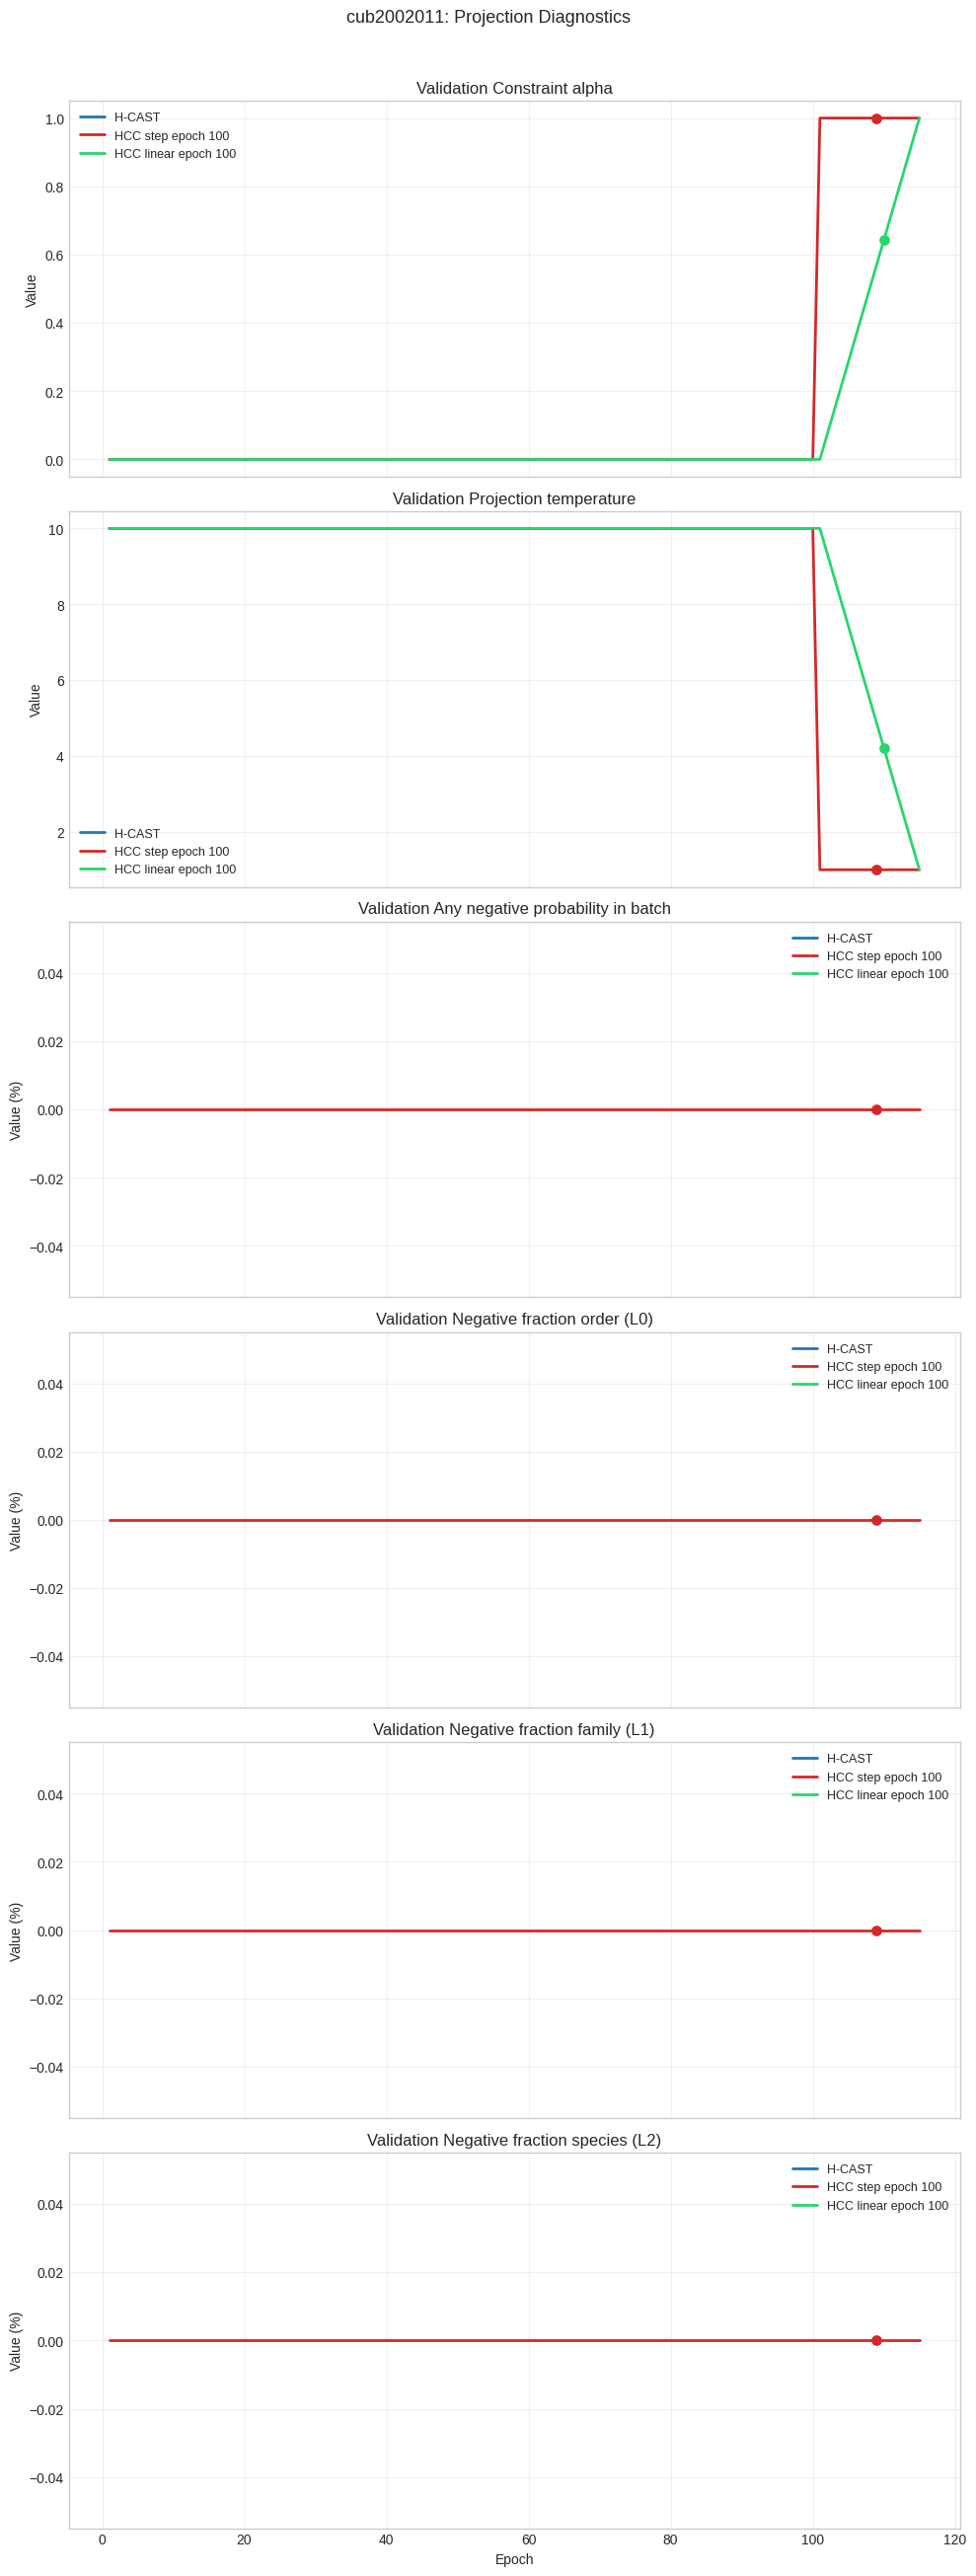

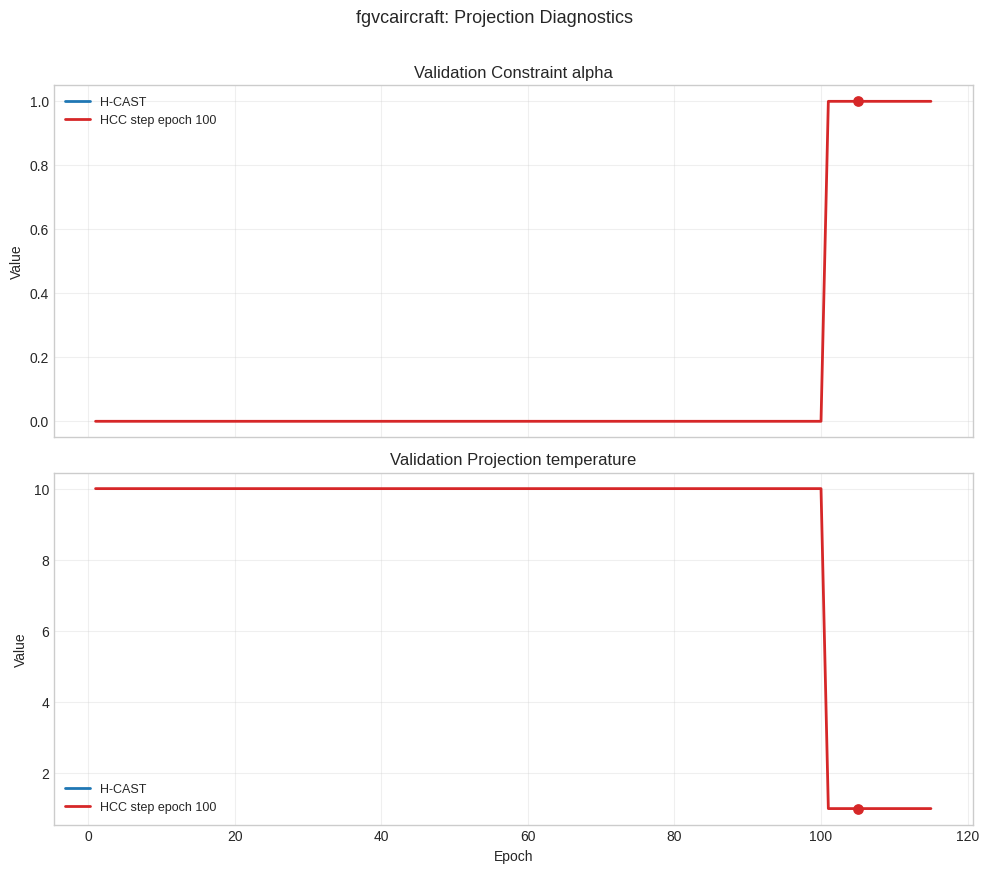

In [44]:
base_diag_specs = [
    ('proj_constraint_alpha', 'Constraint alpha', False),
    ('proj_constraint_strength', 'Constraint strength', False),
    ('proj_temperature', 'Projection temperature', False),
    ('proj_mode_intrinsic_soft', 'Intrinsic-soft mode flag (1=true)', False),
    ('proj_has_negative', 'Any negative probability in batch', True),
]

for dataset_key in dataset_keys:
    dataset_runs = run_data_by_dataset.get(dataset_key, [])
    if not dataset_runs:
        continue

    diag_specs = list(base_diag_specs)
    neg_frac_level_ids = sorted({
        int(key.rsplit('_', 1)[-1])
        for run_data in dataset_runs
        for event in run_data['epoch_events']
        for key in event['val_metrics_norm'].keys()
        if key.startswith('proj_neg_frac_level_') and key.rsplit('_', 1)[-1].isdigit()
    })

    for level_idx in neg_frac_level_ids:
        level_name = get_level_label(level_idx, dataset_runs[0])
        diag_specs.append((
            f'proj_neg_frac_level_{level_idx}',
            f'Negative fraction {level_name} (L{level_idx})',
            True,
        ))

    active_diag_specs = []
    for metric_key, title, is_percent in diag_specs:
        has_finite = False
        for run_data in dataset_runs:
            _, values = get_metric_series(run_data['epoch_events'], metric_key)
            if np.any(np.isfinite(values)):
                has_finite = True
                break
        if has_finite:
            active_diag_specs.append((metric_key, title, is_percent))

    if not active_diag_specs:
        print(f'[{dataset_key}] No projection diagnostics found in selected runs.')
        continue

    fig, axes = plt.subplots(len(active_diag_specs), 1, figsize=(10, 4.3 * len(active_diag_specs)), sharex=True)
    if len(active_diag_specs) == 1:
        axes = [axes]

    for ax, (metric_key, title, is_percent) in zip(axes, active_diag_specs):
        for run_data in dataset_runs:
            epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
            plot_values = values * 100.0 if is_percent else values
            ax.plot(
                epochs,
                plot_values,
                label=run_data['label'],
                color=run_data['color'],
                linewidth=2.0,
            )

            best_event = run_data['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    best_plot_value = best_value * 100.0 if is_percent else best_value
                    ax.scatter(
                        [best_event['epoch']],
                        [best_plot_value],
                        color=run_data['color'],
                        marker='o',
                        s=45,
                        zorder=4,
                    )

        ax.set_title(f'Validation {title}')
        ax.set_ylabel('Value (%)' if is_percent else 'Value')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    axes[-1].set_xlabel('Epoch')
    plt.suptitle(f'{dataset_key}: Projection Diagnostics', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`) and per-level losses (`loss_level_*`).

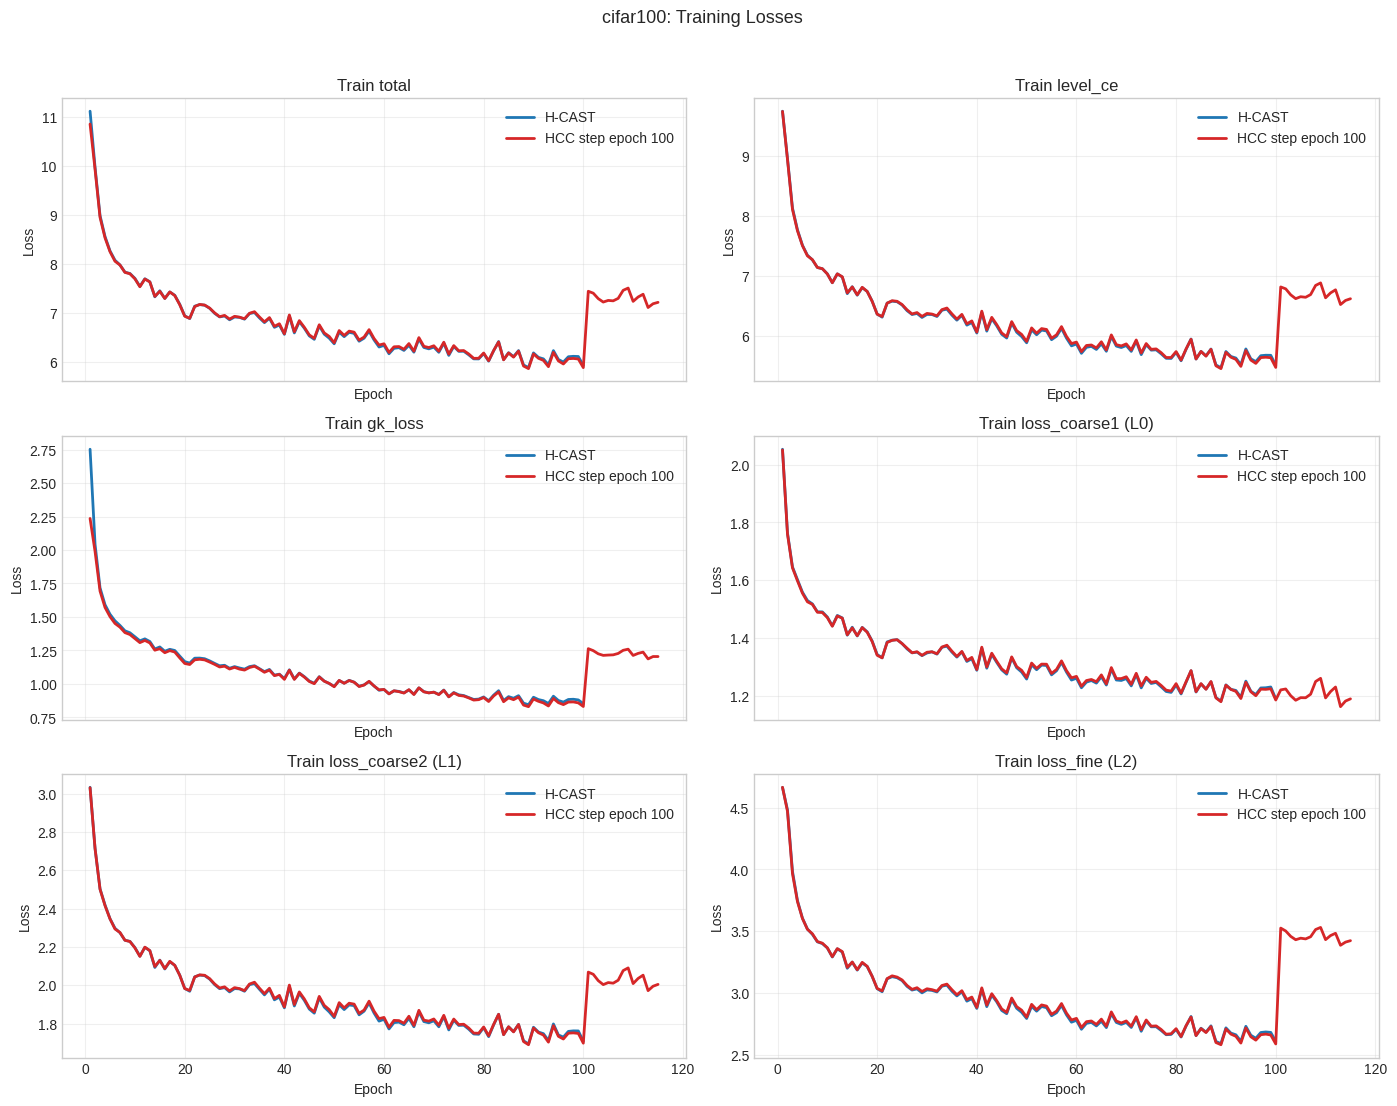

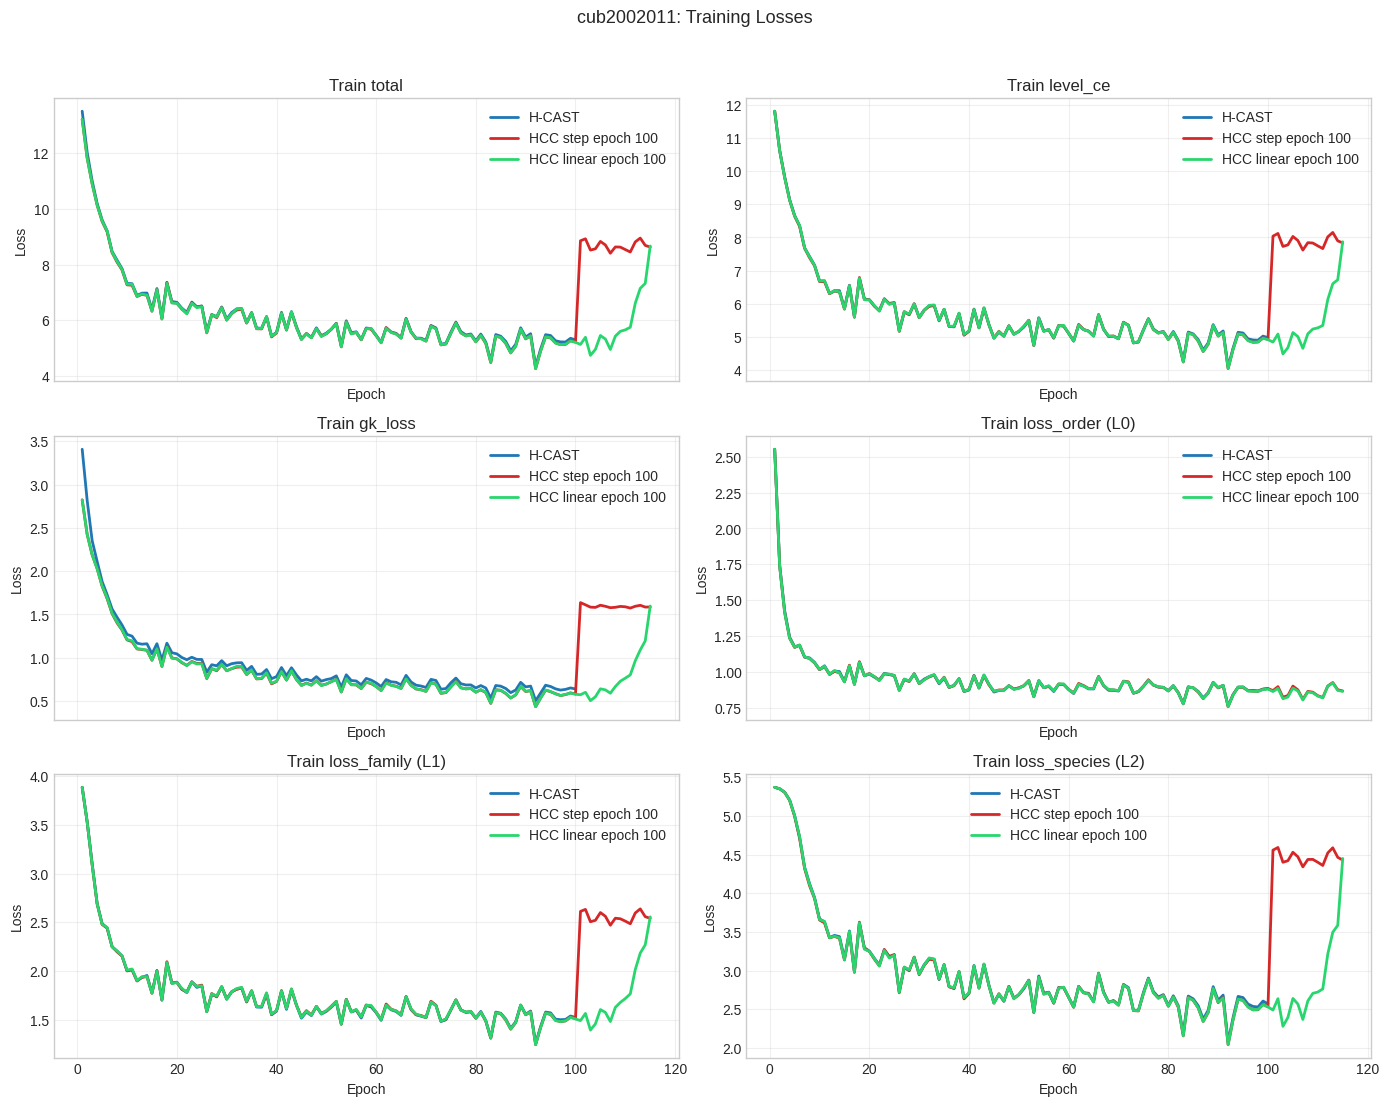

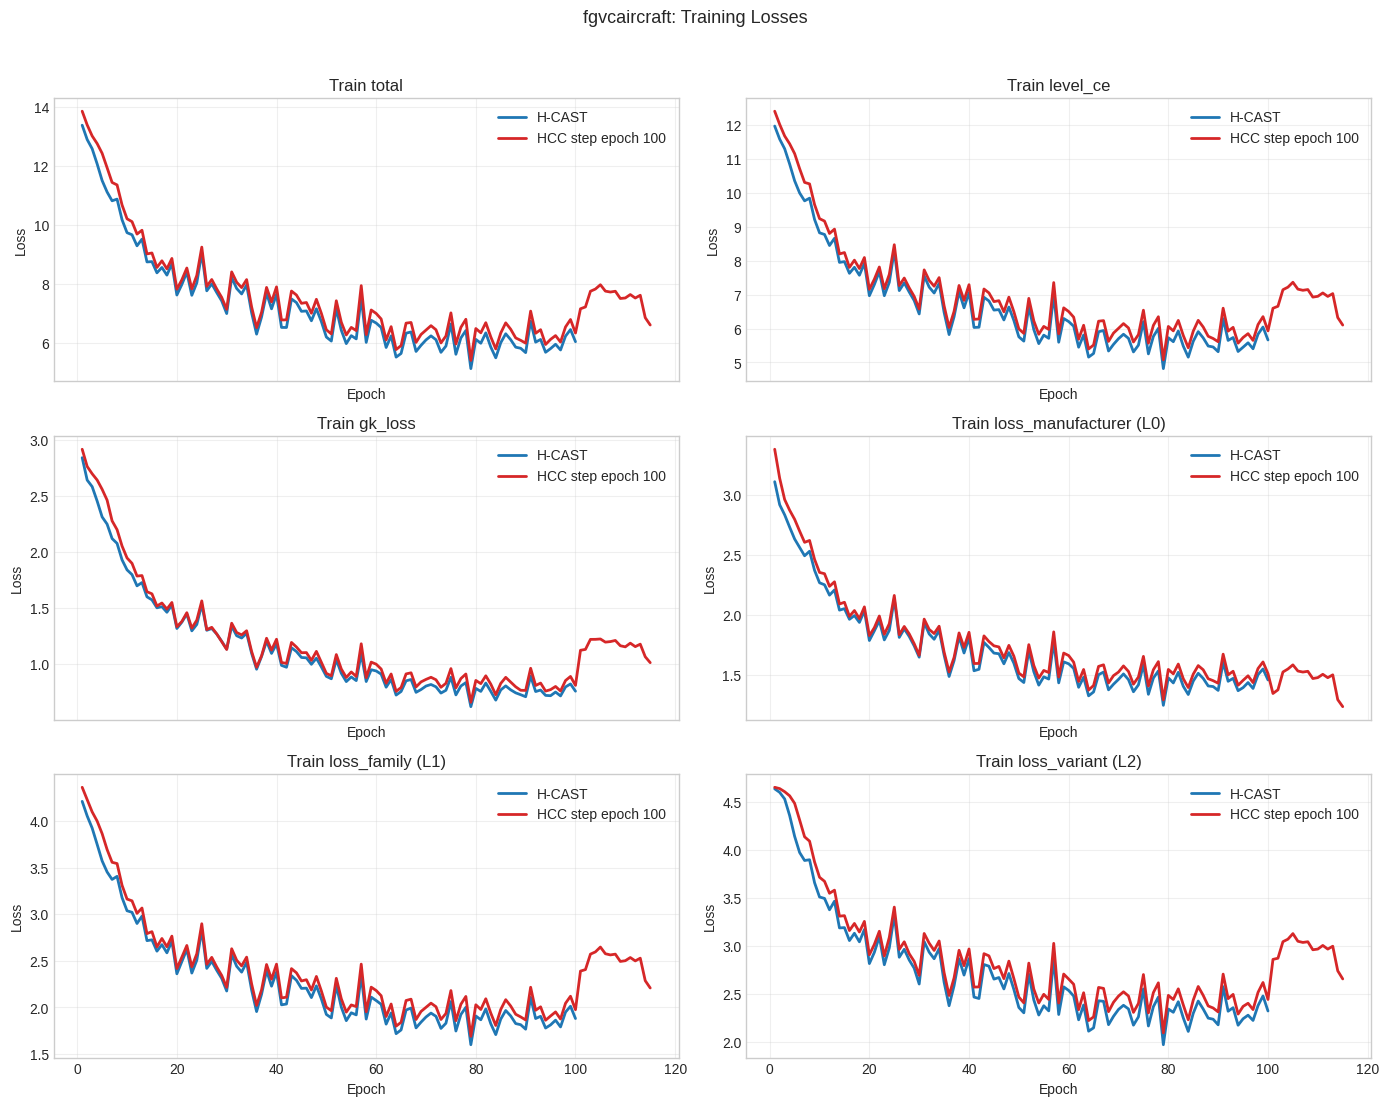

In [45]:
def get_train_loss_series(epoch_events, loss_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event.get('train_losses', {}).get(loss_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)

aggregate_loss_keys = ['total', 'level_ce', 'gk_loss']

for dataset_key in dataset_keys:
    dataset_runs = run_data_by_dataset.get(dataset_key, [])
    if not dataset_runs:
        continue

    level_loss_ids = sorted({
        int(key.rsplit('_', 1)[-1])
        for run_data in dataset_runs
        for event in run_data['epoch_events']
        for key in event.get('train_losses', {}).keys()
        if key.startswith('loss_level_') and key.rsplit('_', 1)[-1].isdigit()
    })

    metric_specs = [(key, key) for key in aggregate_loss_keys]
    for level_idx in level_loss_ids:
        level_name = get_level_label(level_idx, dataset_runs[0])
        metric_specs.append((f'loss_level_{level_idx}', f'loss_{level_name} (L{level_idx})'))

    n_metrics = len(metric_specs)
    ncols = 2
    nrows = int(np.ceil(n_metrics / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, (metric_key, metric_title) in zip(axes, metric_specs):
        for run_data in dataset_runs:
            epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
            ax.plot(
                epochs,
                values,
                label=run_data['label'],
                color=run_data['color'],
                linewidth=2.0,
            )
        ax.set_title(f'Train {metric_title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        ax.legend()

    for ax in axes[n_metrics:]:
        ax.axis('off')

    plt.suptitle(f'{dataset_key}: Training Losses', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



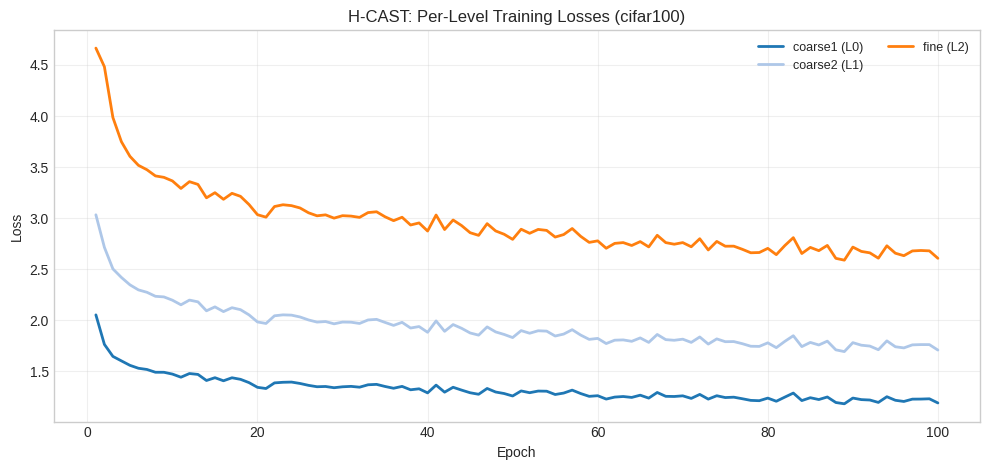

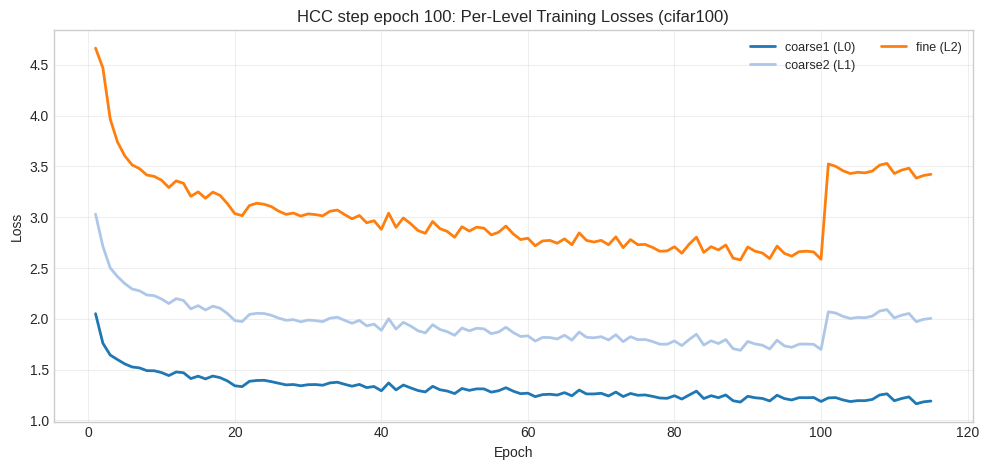

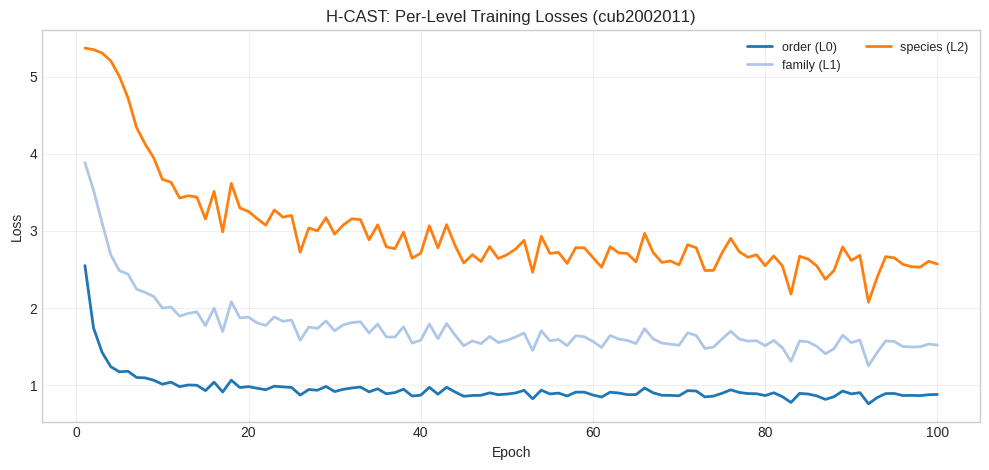

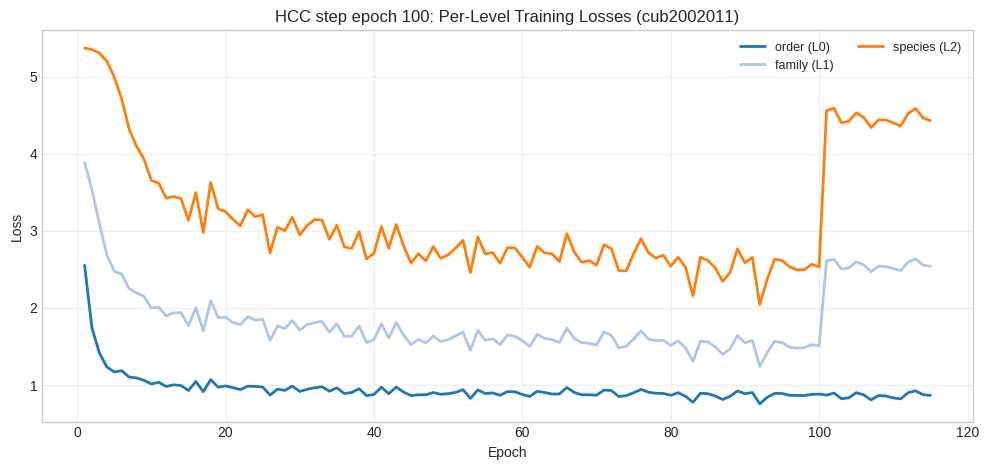

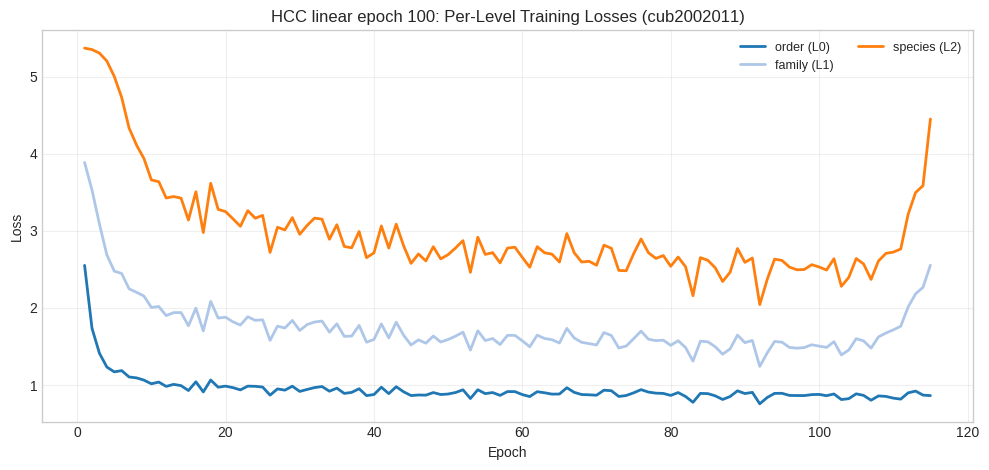

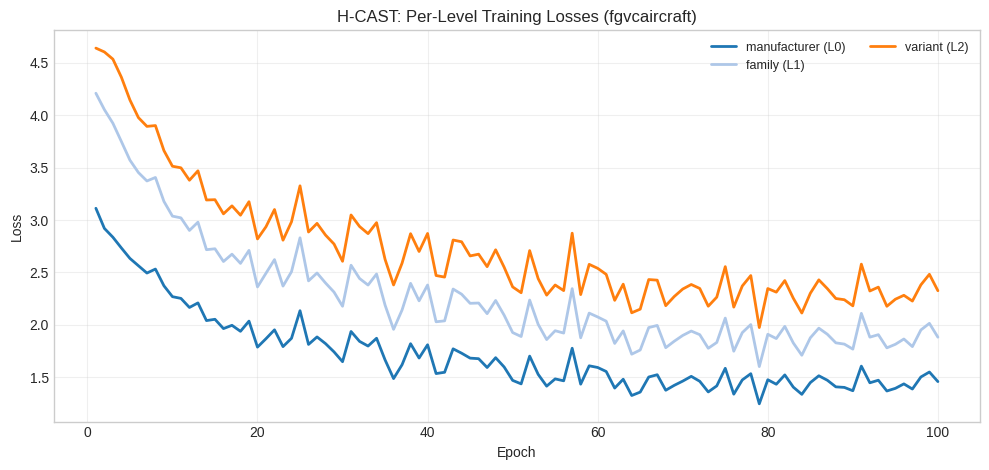

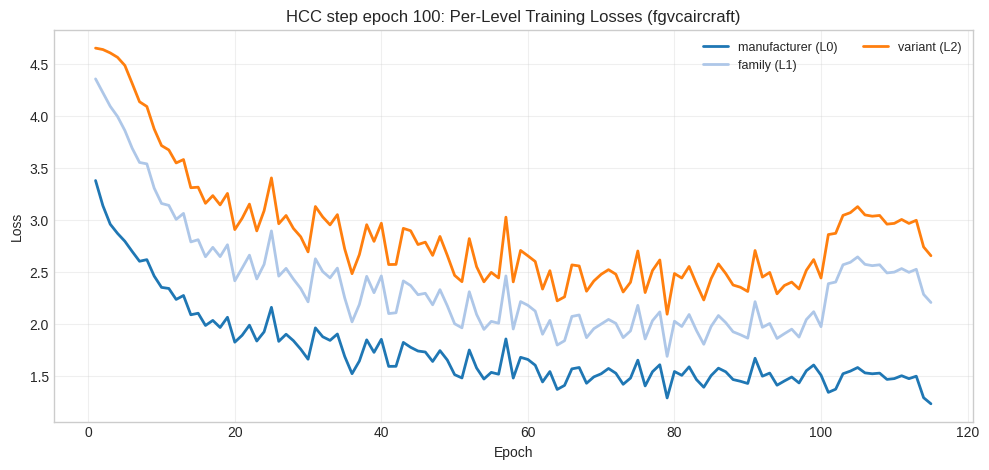

In [46]:
for dataset_key in dataset_keys:
    dataset_runs = run_data_by_dataset.get(dataset_key, [])
    if not dataset_runs:
        continue

    for run_data in dataset_runs:
        all_loss_keys = sorted({
            key
            for event in run_data['epoch_events']
            for key in event.get('train_losses', {}).keys()
        })

        level_loss_ids = sorted({
            int(key.rsplit('_', 1)[-1])
            for key in all_loss_keys
            if key.startswith('loss_level_') and key.rsplit('_', 1)[-1].isdigit()
        })

        if not level_loss_ids:
            print(f"[{dataset_key}] No per-level train losses for {run_data['label']}")
            continue

        fig, ax = plt.subplots(figsize=(10, 4.8))
        cmap = plt.get_cmap('tab20')
        plotted = 0

        for idx, level_idx in enumerate(level_loss_ids):
            metric_key = f'loss_level_{level_idx}'
            epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
            if np.all(~np.isfinite(values)):
                continue

            level_name = get_level_label(level_idx, run_data)
            ax.plot(
                epochs,
                values,
                label=f'{level_name} (L{level_idx})',
                color=cmap(idx % 20),
                linewidth=2.0,
            )
            plotted += 1

        if plotted == 0:
            plt.close(fig)
            print(f"[{dataset_key}] No finite per-level train losses for {run_data['label']}")
            continue

        ax.set_title(f"{run_data['label']}: Per-Level Training Losses ({dataset_key})")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=9)
        plt.tight_layout()
        plt.show()



## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

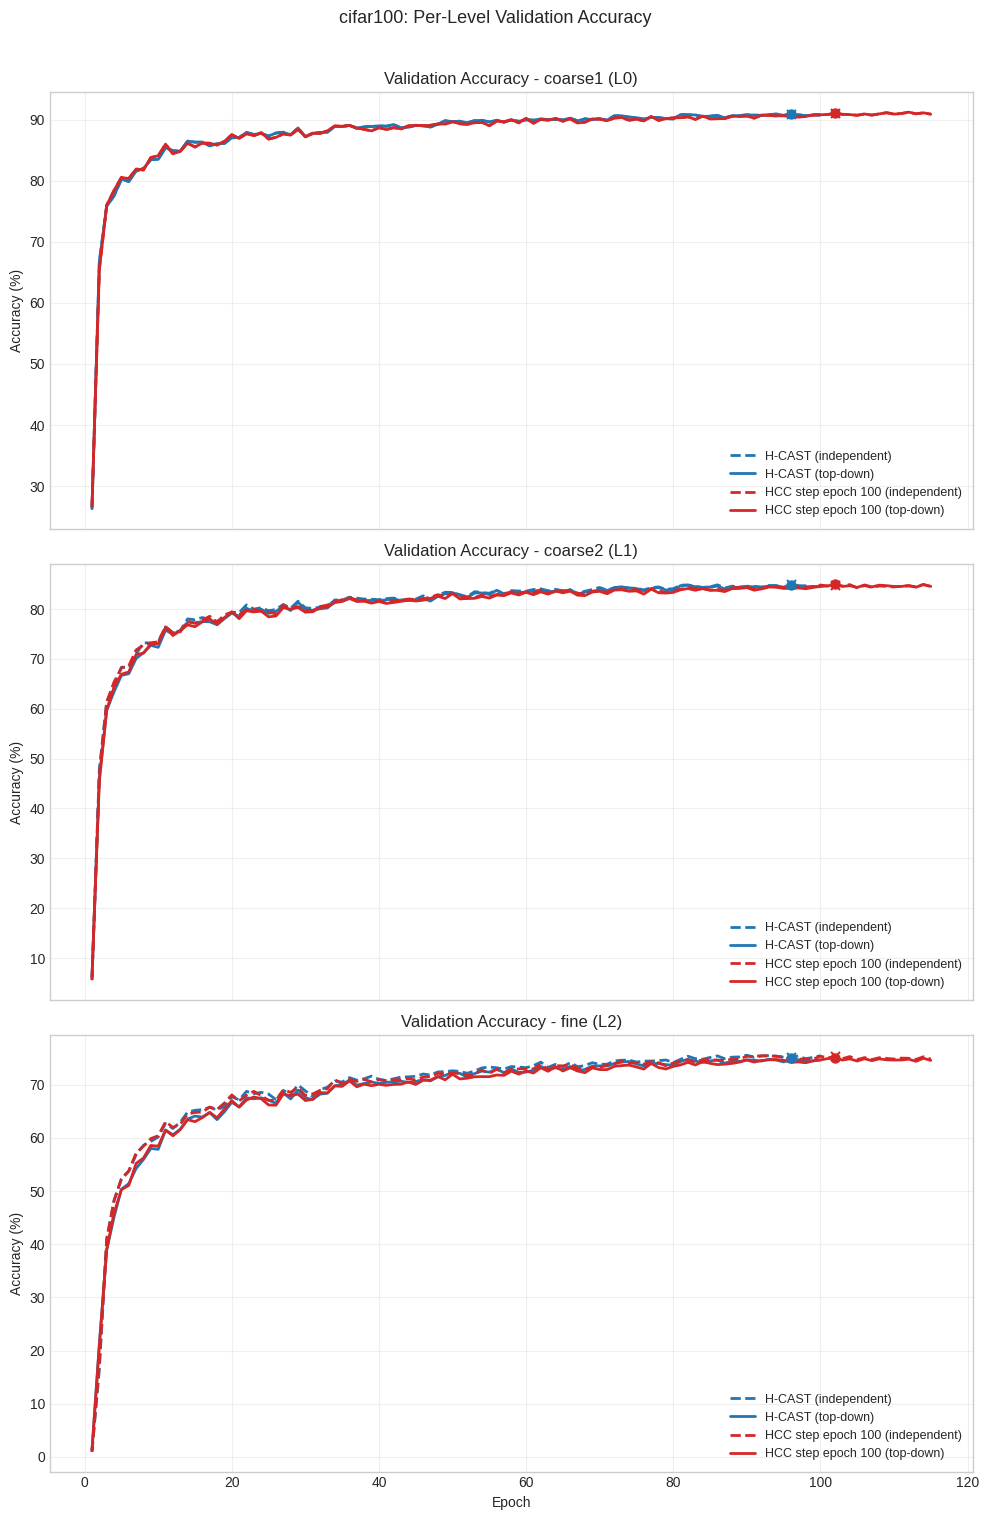

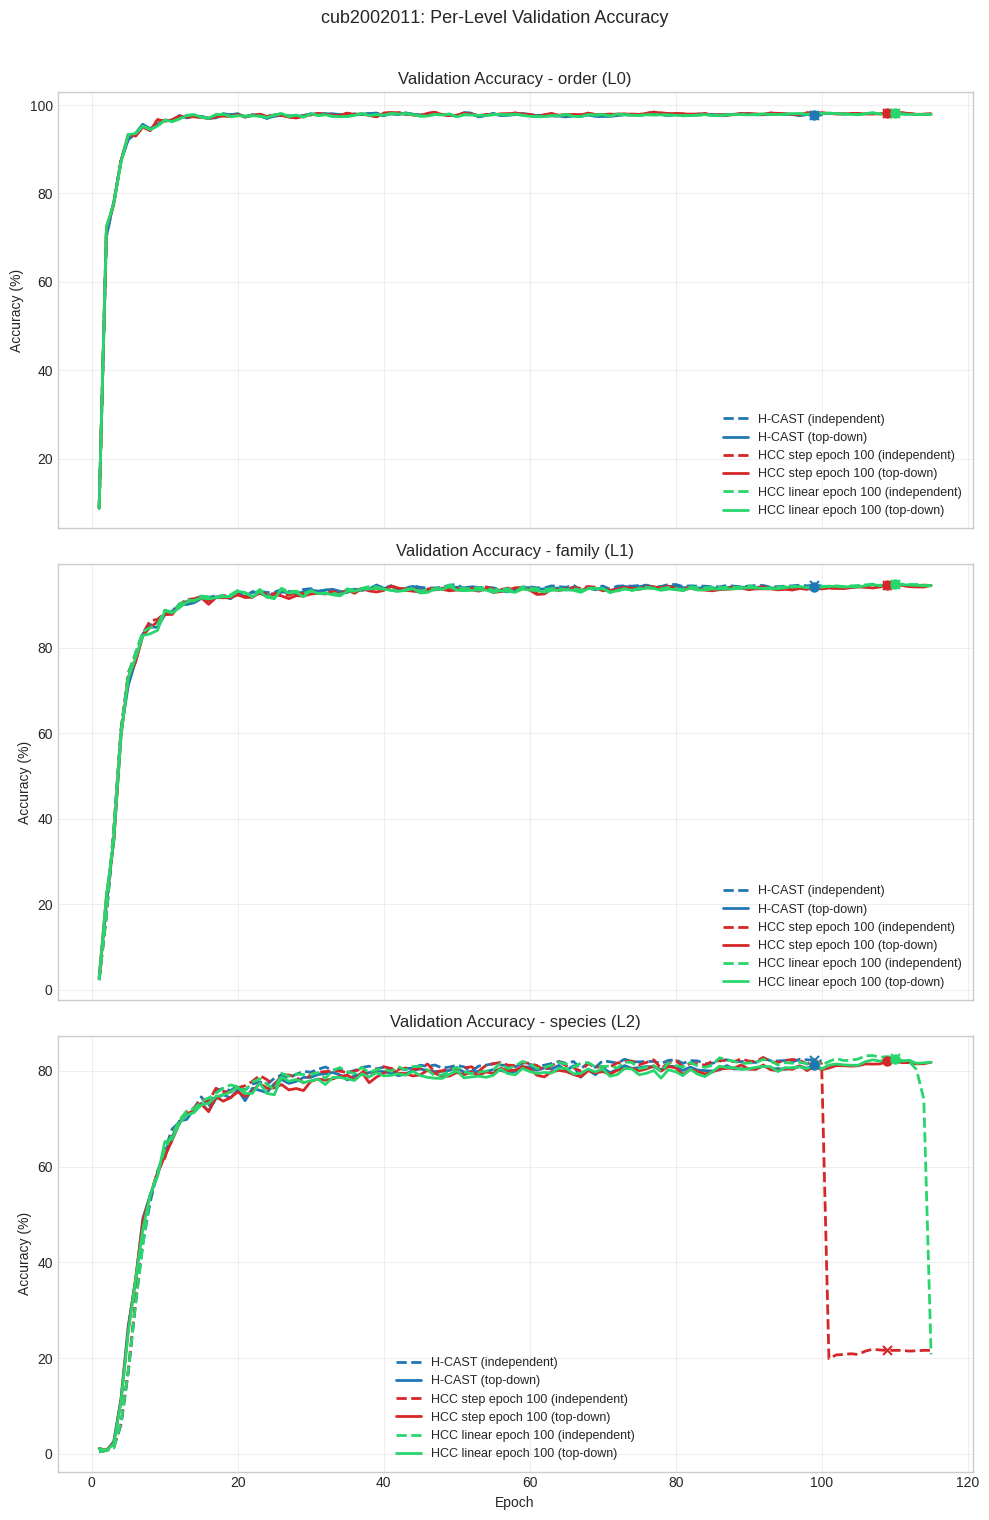

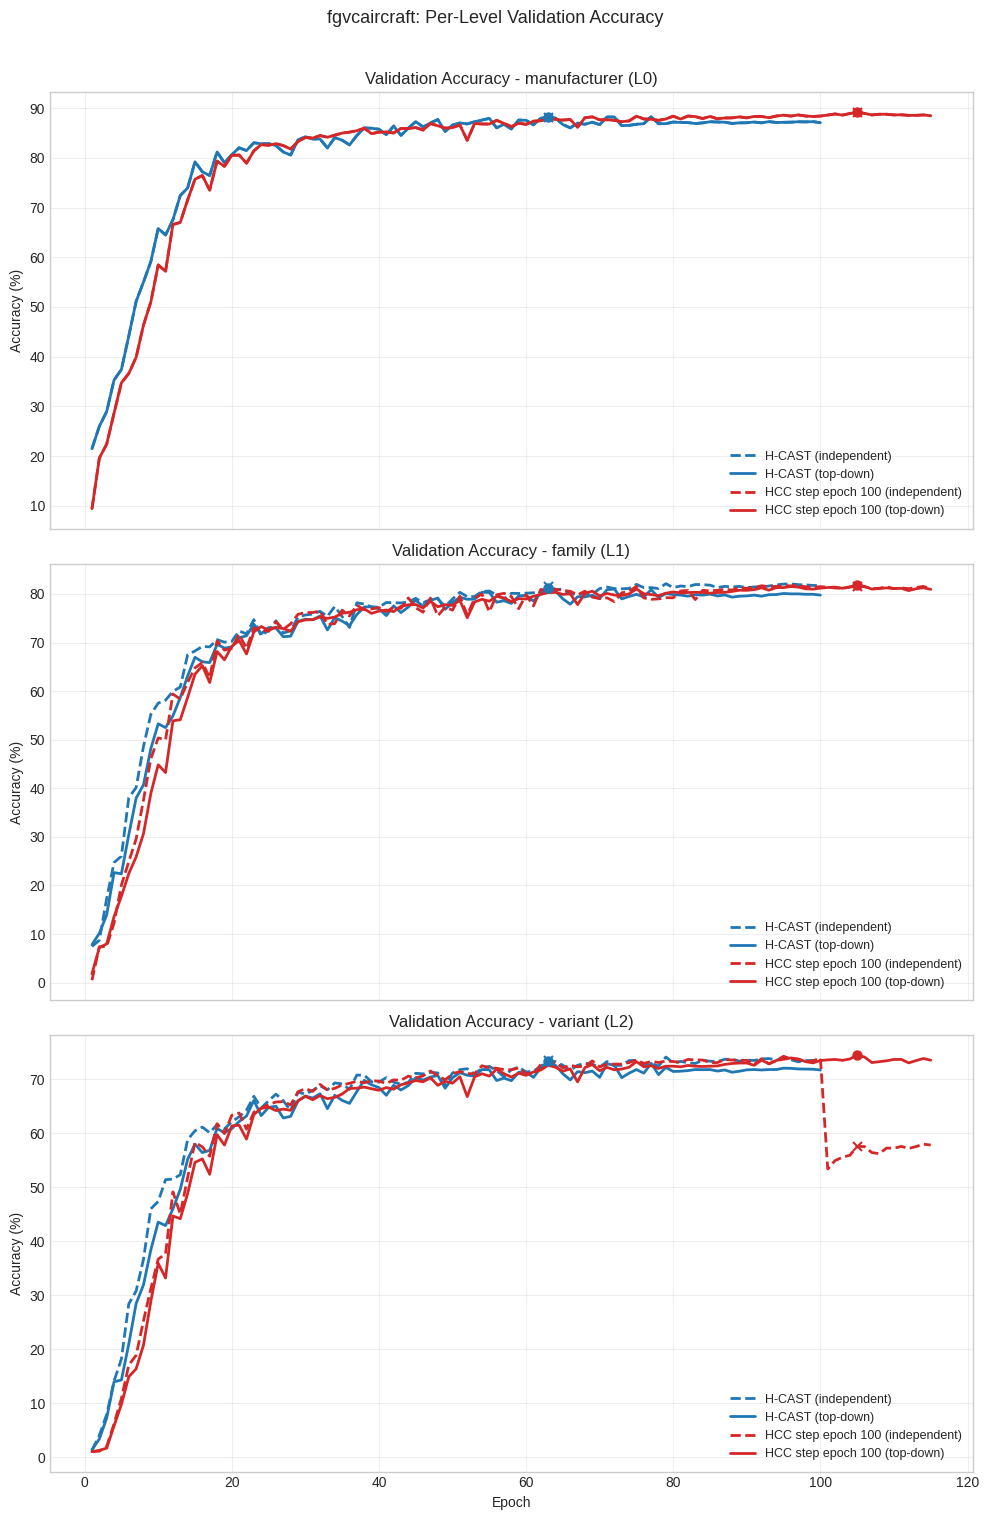

In [47]:
mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

for dataset_key in dataset_keys:
    dataset_runs = run_data_by_dataset.get(dataset_key, [])
    if not dataset_runs:
        continue

    all_level_ids = sorted({
        int(key.rsplit('_', 1)[-1])
        for run_data in dataset_runs
        for event in run_data['epoch_events']
        for key in event['val_metrics_norm'].keys()
        if (
            (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
            and key.rsplit('_', 1)[-1].isdigit()
        )
    })

    if not all_level_ids:
        print(f'[{dataset_key}] No per-level validation accuracy metrics found in selected runs.')
        continue

    fig, axes = plt.subplots(len(all_level_ids), 1, figsize=(10, 5 * len(all_level_ids)), sharex=True)
    if len(all_level_ids) == 1:
        axes = [axes]

    for ax, level_idx in zip(axes, all_level_ids):
        level_label = get_level_label(level_idx, dataset_runs[0])
        for run_data in dataset_runs:
            for mode_key, line_style, mode_label, marker in mode_specs:
                metric_key = f'acc_level_{mode_key}_{level_idx}'
                epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
                ax.plot(
                    epochs,
                    values * 100.0,
                    label=f"{run_data['label']} ({mode_label})",
                    color=run_data['color'],
                    linestyle=line_style,
                    linewidth=2.0,
                )

                best_event = run_data['best_epoch_event']
                if best_event is not None:
                    best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                    if np.isfinite(best_value):
                        ax.scatter(
                            [best_event['epoch']],
                            [best_value * 100.0],
                            color=run_data['color'],
                            marker=marker,
                            s=42,
                            zorder=4,
                        )

        ax.set_title(f'Validation Accuracy - {level_label} (L{level_idx})')
        ax.set_ylabel('Accuracy (%)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    axes[-1].set_xlabel('Epoch')
    plt.suptitle(f'{dataset_key}: Per-Level Validation Accuracy', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset.

In [48]:
def fmt_pct(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{100.0 * x:.2f}%'


def fmt_delta_pp(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{100.0 * x:.2f} pp'


def fmt_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{x:.3f}'


def fmt_delta_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{x:.3f}'


def metric_goal_is_lower_better(metric_key):
    return metric_key.startswith('tice_') or metric_key.startswith('ahd_')


def metric_goal_arrow(metric_key):
    return '↓' if metric_goal_is_lower_better(metric_key) else '↑'


def is_distance_metric(metric_key):
    return metric_key.startswith('ahd_')


def fmt_value(metric_key, value):
    return fmt_edges(value) if is_distance_metric(metric_key) else fmt_pct(value)


def fmt_delta(metric_key, delta_value):
    return fmt_delta_edges(delta_value) if is_distance_metric(metric_key) else fmt_delta_pp(delta_value)


def _merged_comp_cell(metric_key, comp_value, base_value):
    comp_txt = fmt_value(metric_key, comp_value)
    if not np.isfinite(base_value) or not np.isfinite(comp_value):
        return comp_txt
    delta_txt = fmt_delta(metric_key, comp_value - base_value)
    return f"{comp_txt} ({delta_txt})"


def _best_indices(metric_key, values):
    finite_pairs = [(idx, val) for idx, val in enumerate(values) if np.isfinite(val)]
    if not finite_pairs:
        return set()

    if metric_goal_is_lower_better(metric_key):
        best_value = min(val for _, val in finite_pairs)
    else:
        best_value = max(val for _, val in finite_pairs)

    return {idx for idx, val in finite_pairs if np.isclose(val, best_value, rtol=1e-9, atol=1e-12)}


for dataset_key in dataset_keys:
    dataset_runs = run_data_by_dataset.get(dataset_key, [])
    if len(dataset_runs) < 2:
        print(f'[{dataset_key}] Skipping final test table: need at least two runs (base + comparison).')
        continue

    base = dataset_runs[0]

    level_ids_from_test = {
        int(key.rsplit('_', 1)[-1])
        for run_data in dataset_runs
        for key in run_data.get('test_metrics', {}).keys()
        if (
            (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
            and key.rsplit('_', 1)[-1].isdigit()
        )
    }
    all_level_ids = sorted(level_ids_from_test)
    if not all_level_ids:
        all_level_ids = sorted({
            int(key.rsplit('_', 1)[-1])
            for run_data in dataset_runs
            for event in run_data['epoch_events']
            for key in event['val_metrics_norm'].keys()
            if (
                (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
                and key.rsplit('_', 1)[-1].isdigit()
            )
        })

    metric_rows = [
        ('fpa_independent', 'FPA independent'),
        ('fpa_topdown', 'FPA top-down'),
        ('weighted_ap_independent', 'wAP independent'),
        ('weighted_ap_topdown', 'wAP top-down'),
        ('tice_independent', 'TICE independent'),
        ('tice_topdown', 'TICE top-down'),
        ('ahd_independent', 'AHD independent'),
        ('ahd_topdown', 'AHD top-down'),
    ]

    for level_idx in all_level_ids:
        level_label = get_level_label(level_idx, base)
        metric_rows.append((f'acc_level_independent_{level_idx}', f'Acc independent {level_label} (L{level_idx})'))
        metric_rows.append((f'acc_level_topdown_{level_idx}', f'Acc top-down {level_label} (L{level_idx})'))

    values_by_metric = {}
    best_by_metric = {}
    for metric_key, _ in metric_rows:
        metric_values = [float(run_data['test_metrics'].get(metric_key, np.nan)) for run_data in dataset_runs]
        values_by_metric[metric_key] = metric_values
        best_by_metric[metric_key] = _best_indices(metric_key, metric_values)

    header_labels = ['Metric'] + [run_data['label'] for run_data in dataset_runs]
    table_lines = [
        f"### Dataset: `{dataset_key}`",
        f"Baseline run: **{base['label']}**",
        '',
        '| ' + ' | '.join(header_labels) + ' |',
        '|---|' + '|'.join(['---:'] * (len(header_labels) - 1)) + '|',
    ]

    for metric_key, metric_name in metric_rows:
        metric_label = f"{metric_name} {metric_goal_arrow(metric_key)}"
        row_cells = [metric_label]

        values = values_by_metric[metric_key]
        for run_idx, value in enumerate(values):
            if run_idx == 0:
                cell = fmt_value(metric_key, value)
            else:
                cell = _merged_comp_cell(metric_key, value, values[0])

            if run_idx in best_by_metric[metric_key] and cell != 'n/a':
                cell = f"**{cell}**"

            row_cells.append(cell)

        table_lines.append('| ' + ' | '.join(row_cells) + ' |')

    show_markdown('\n'.join(table_lines))


### Dataset: `cifar100`
Baseline run: **H-CAST**

| Metric | H-CAST | HCC step epoch 100 |
|---|---:|---:|
| FPA independent ↑ | 71.96% | **73.96% (+2.00 pp)** |
| FPA top-down ↑ | 73.81% | **74.50% (+0.69 pp)** |
| wAP independent ↑ | 77.03% | **77.29% (+0.26 pp)** |
| wAP top-down ↑ | 76.49% | **77.14% (+0.65 pp)** |
| TICE independent ↓ | 8.38% | **2.35% (-6.03 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 1.075 | **1.021 (-0.055)** |
| AHD top-down ↓ | 1.031 | **0.999 (-0.032)** |
| Acc independent coarse1 (L0) ↑ | 90.29% | **90.62% (+0.32 pp)** |
| Acc top-down coarse1 (L0) ↑ | 90.29% | **90.62% (+0.32 pp)** |
| Acc independent coarse2 (L1) ↑ | 84.53% | **84.92% (+0.39 pp)** |
| Acc top-down coarse2 (L1) ↑ | 84.37% | **84.93% (+0.57 pp)** |
| Acc independent fine (L2) ↑ | 74.46% | **74.70% (+0.23 pp)** |
| Acc top-down fine (L2) ↑ | 73.81% | **74.50% (+0.69 pp)** |

### Dataset: `cub2002011`
Baseline run: **H-CAST**

| Metric | H-CAST | HCC step epoch 100 | HCC linear epoch 100 |
|---|---:|---:|---:|
| FPA independent ↑ | 79.38% | 19.60% (-59.78 pp) | **80.81% (+1.44 pp)** |
| FPA top-down ↑ | 81.12% | 82.04% (+0.92 pp) | **82.08% (+0.97 pp)** |
| wAP independent ↑ | 84.10% | 36.00% (-48.10 pp) | **85.08% (+0.98 pp)** |
| wAP top-down ↑ | 83.87% | 84.73% (+0.86 pp) | **84.76% (+0.89 pp)** |
| TICE independent ↓ | 6.16% | 78.31% (+72.15 pp) | **5.12% (-1.04 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.584 | 1.761 (+1.176) | **0.535 (-0.050)** |
| AHD top-down ↓ | 0.546 | **0.506 (-0.040)** | 0.508 (-0.038) |
| Acc independent order (L0) ↑ | 98.10% | **98.45% (+0.36 pp)** | 98.32% (+0.22 pp) |
| Acc top-down order (L0) ↑ | 98.10% | **98.45% (+0.36 pp)** | 98.32% (+0.22 pp) |
| Acc independent family (L1) ↑ | 93.71% | 94.26% (+0.55 pp) | **94.35% (+0.64 pp)** |
| Acc top-down family (L1) ↑ | 93.51% | **94.23% (+0.72 pp)** | 94.21% (+0.70 pp) |
| Acc independent species (L2) ↑ | 81.36% | 20.87% (-60.49 pp) | **82.45% (+1.09 pp)** |
| Acc top-down species (L2) ↑ | 81.12% | 82.04% (+0.92 pp) | **82.08% (+0.97 pp)** |

### Dataset: `fgvcaircraft`
Baseline run: **H-CAST**

| Metric | H-CAST | HCC step epoch 100 |
|---|---:|---:|
| FPA independent ↑ | **69.05%** | 51.97% (-17.08 pp) |
| FPA top-down ↑ | **72.68%** | 72.00% (-0.68 pp) |
| wAP independent ↑ | **78.39%** | 68.75% (-9.64 pp) |
| wAP top-down ↑ | **77.71%** | 77.07% (-0.64 pp) |
| TICE independent ↓ | **13.00%** | 38.54% (+25.54 pp) |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | **1.277** | 1.639 (+0.362) |
| AHD top-down ↓ | **1.178** | 1.223 (+0.045) |
| Acc independent manufacturer (L0) ↑ | **87.89%** | 86.65% (-1.23 pp) |
| Acc top-down manufacturer (L0) ↑ | **87.89%** | 86.65% (-1.23 pp) |
| Acc independent family (L1) ↑ | **80.97%** | 80.43% (-0.54 pp) |
| Acc top-down family (L1) ↑ | **80.55%** | 80.21% (-0.34 pp) |
| Acc independent variant (L2) ↑ | **73.74%** | 55.21% (-18.53 pp) |
| Acc top-down variant (L2) ↑ | **72.68%** | 72.00% (-0.68 pp) |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
